# Phân loại tin tức VietNamNet bằng PhoBERT Base v2

**Bài toán**: Phân loại tự động bài báo tiếng Việt vào **19 chủ đề**.

| Bước | Nội dung |
|------|----------|
| **1. Load data** | Đọc 19 file parquet từ thư mục Dataset |
| **2. Khám phá dữ liệu** | Phân bố class, độ dài văn bản, bảng tổng hợp |
| **3. Tiền xử lý** | ViTokenizer, không loại stopwords vì BERT tự học ngữ cảnh |
| **4. Tokenize** | Head-Tail 127+127 tokens, PhoBERT tokenizer |
| **5. Huấn luyện** | PhoBERT Base v2, WeightedTrainer, class_weight=balanced |
| **6. Đánh giá** | Báo cáo phân loại, ma trận nhầm lẫn, F1 theo từng chủ đề |
| **7. Export** | Lưu model config và metadata |
| **8. Calibration** | Temperature scaling và tinh chỉnh threshold |
| **9. Chẩn đoán** | In ra các tín hiệu cần xem để cải thiện mô hình |

> **Mô hình**: `vinai/phobert-base-v2` · MAX_LENGTH=256 · Head+Tail · class_weight=balanced
>
> **Caching**: ViTokenize lưu ở `temp/processed_data.pkl`, model lưu ở `model/`.


---
## Section 0 - Setup
Chạy **mỗi lần** mở notebook.


In [1]:
# -- Kiểm tra thư viện ----------------------------------------------------
import importlib, sys

_REQUIRED = {
    "pandas":       "pandas",
    "numpy":        "numpy",
    "torch":        "torch",
    "matplotlib":   "matplotlib",
    "seaborn":      "seaborn",
    "tqdm":         "tqdm",
    "sklearn":      "scikit-learn",
    "transformers": "transformers",
    "pyarrow":      "pyarrow",
    "scipy":        "scipy",
    "accelerate":   "accelerate",
}

_missing = {pkg for mod, pkg in _REQUIRED.items() if importlib.util.find_spec(mod) is None}

if _missing:
    print("=" * 60)
    print("  KHÔNG THỂ, TIẾP TỤC -- Thiếu thư viện")
    print("=" * 60)
    print("  Các gói chưa được cài:")
    for _p in sorted(_missing):
        print(f"    - {_p}")
    print()
    _pip = " ".join(sorted(_missing))
    print(f"  Chạy lệnh sau rồi khởi động lại kernel:")
    print(f"     pip install {_pip}")
    print()
    print("  Lưu ý: torch cần cài đúng phiên bản CUDA.")
    print("  Xem: https://pytorch.org/get-started/locally/")
    print("=" * 60)
    raise SystemExit("Thiếu thư viện. Xem hướng dẫn ở trên.")

# -- Import ----------------------------------------------------------------
import os, re, pickle, time, datetime, json, warnings, shutil
warnings.filterwarnings("ignore")
os.environ.setdefault("PYTORCH_ALLOC_CONF", "expandable_segments:True")

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm
from matplotlib.patches import Patch
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, EarlyStoppingCallback, TrainerCallback, Trainer,
)
from torch.utils.data import Dataset as TorchDataset

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

# --
if not torch.cuda.is_available():
    print("=" * 60)
    print("  KHÔNG THỂ, TIẾP TỤC -- Không tìm thấy GPU/CUDA")
    print("=" * 60)
    print("  PhoBERT cần GPU để huấn luyện trong thời gian hợp lý.")
    print("  Giải pháp:")
    print("    - Dùng Google Colab (T4 miễn phí, A100 trả phí)")
    print("    - Dùng máy có GPU NVIDIA (khuyến nghị >= 6 GB VRAM)")
    print("    - Cài CUDA + PyTorch GPU: https://pytorch.org/get-started/locally/")
    print("=" * 60)
    raise SystemExit("Không có GPU. Xem hướng dẫn ở trên.")

device      = "cuda"
gpu_name    = torch.cuda.get_device_name(0)
vram_gb     = torch.cuda.get_device_properties(0).total_memory / 1024**3
cc_major    = torch.cuda.get_device_properties(0).major
cc_minor    = torch.cuda.get_device_properties(0).minor
compute_cap = cc_major + cc_minor / 10

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True

print(f"Tất cả thư viện sẵn sàng - Python {sys.version.split()[0]}")
print(f"GPU  : {gpu_name}  ({vram_gb:.1f} GB VRAM)  Compute {cc_major}.{cc_minor}  CUDA {torch.version.cuda}")
print(f"PyTorch : {torch.__version__}")

Tất cả thư viện sẵn sàng - Python 3.13.12
GPU  : NVIDIA RTX A3000 12GB Laptop GPU  (12.0 GB VRAM)  Compute 8.6  CUDA 12.8
PyTorch : 2.10.0+cu128


In [2]:
# -- Đường dẫn ----------------------------------------------------------
NOTEBOOK_DIR   = os.getcwd()
DATASET_FOLDER = os.path.normpath(os.path.join(NOTEBOOK_DIR, '..', 'Dataset'))
TEMP_DIR       = os.path.join(NOTEBOOK_DIR, 'temp')
RESULTS_DIR    = os.path.join(NOTEBOOK_DIR, 'results')
MODEL_DIR      = os.path.join(NOTEBOOK_DIR, 'model')

for _d in [TEMP_DIR, RESULTS_DIR, MODEL_DIR]:
    os.makedirs(_d, exist_ok=True)

PROCESSED_DATA_PATH = os.path.join(TEMP_DIR,  'processed_data.pkl')
TRAIN_HISTORY_PATH  = os.path.join(MODEL_DIR, 'train_history.pkl')
LABEL_CONFIG_PATH   = os.path.join(MODEL_DIR, 'label_config.json')

# --
# Để thay đổi: chỉnh sửa tay các biến này trước khi chạy huấn luyện.
MODEL_NAME   = 'vinai/phobert-base-v2'
MAX_LENGTH   = 256
BATCH_SIZE   = 32
GRAD_ACCUM   = 2
EVAL_BATCH   = 64
LR           = 2e-5
NUM_EPOCHS   = 7
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 200
BF16         = True
FP16         = False
TEST_SIZE    = 0.15
RANDOM_STATE = 42

# -- Boost nhẹ cho các class yếu (nhân thêm sau balanced weight) ----------
# Chọn mức tăng nhẹ để ưu tiên recall mà không làm precision giảm quá mạnh.
MANUAL_CLASS_BOOST = {
    'Dân tộc - Tôn giáo':     1.35,
    'Kinh doanh':             1.15,
    'Thời sự':                1.15,
    'Thị trường tiêu dùng':   1.10,
    'Đời sống':               1.10,
}

# --
_bf16_ok = (compute_cap >= 8.0)   # Ampere trở lên
_fp16_ok = (compute_cap >= 7.0)   # Turing trở lên
_tiers = [
    (24,  'vinai/phobert-large',   64,  1, 128, True,      False,    '>= 24 GB (RTX 3090/4090)  [ĐANG DÙNG]'),
    (16,  'vinai/phobert-large',   32,  2,  64, _bf16_ok,  not _bf16_ok and _fp16_ok, '16-23 GB (RTX 3080Ti/4080)'),
    (10,  'vinai/phobert-base-v2', 32,  2,  64, _bf16_ok,  not _bf16_ok and _fp16_ok, '10-15 GB (RTX 3080 10GB / A3000 12GB)'),
    ( 6,  'vinai/phobert-base-v2', 16,  4,  32, False,     _fp16_ok, ' 6-9  GB (RTX 3060 / 2060)'),
    ( 0,  'vinai/phobert-base-v2',  8,  8,  16, False,     _fp16_ok, ' < 6  GB (rất chậm - nên dùng Google Colab)'),
]
print()
print(f'GPU của bạn: {gpu_name}  ({vram_gb:.1f} GB VRAM)  Compute {cc_major}.{cc_minor}')
print()
print('Khuyến nghị tham số theo VRAM:')
print('-' * 85)
print(f'{"Model":<26} {"Batch":>5} {"Accum":>5} {"Eff":>5} {"Eval":>5}  {"BF16":>5}  {"FP16":>5}  Tier')
print('-' * 85)
for _vmin, _m, _bs, _ga, _eb, _b16, _f16, _tier in _tiers:
    print(f'{_m:<26} {_bs:>5} {_ga:>5} {_bs*_ga:>5} {_eb:>5}  {str(_b16):>5}  {str(_f16):>5}  {_tier}')
print('-' * 85)
print(f'Hiện tại đang dùng: BATCH={BATCH_SIZE} ACCUM={GRAD_ACCUM} BF16={BF16} MODEL={MODEL_NAME}')
print('Nếu GPU yếu hơn, sửa tay các biến BATCH_SIZE / GRAD_ACCUM / MODEL_NAME / BF16 / FP16 ở trên.')

# -- Label map -----------------------------------------------------------
LABEL_MAP = {
    'ban-doc':               'Bạn đọc',
    'bao-ve-nguoi-tieu-dung':'Bảo vệ người tiêu dùng',
    'bat-dong-san':          'Bất động sản',
    'chinh-tri':             'Chính trị',
    'cong-nghe':             'Công nghệ',
    'dan-toc-ton-giao':      'Dân tộc - Tôn giáo',
    'doi-song':              'Đời sống',
    'du-lich':               'Du lịch',
    'giao-duc':              'Giáo dục',
    'kinh-doanh':            'Kinh doanh',
    'oto-xe-may':            'Ô tô - Xe máy',
    'phap-luat':             'Pháp luật',
    'suc-khoe':              'Sức khỏe',
    'the-gioi':              'Thế giới',
    'the-thao':              'Thể thao',
    'thi-truong-tieu-dung':  'Thị trường tiêu dùng',
    'thoi-su':               'Thời sự',
    'tuan-viet-nam':         'Tuần Việt Nam',
    'van-hoa-giai-tri':      'Văn hóa - Giải trí',
}

# -- Helpers -------------------------------------------------------------
_T0 = time.time()

def log(msg, level='INFO'):
    icons = {'INFO':'i','OK':'OK','WARN':'!!','SAVE':'>>','GPU':'GPU'}
    elapsed = time.time() - _T0
    ts = datetime.datetime.now().strftime('%H:%M:%S')
    print(f'[{ts}][{elapsed:6.1f}s] {icons.get(level," ")} {msg}', flush=True)

class timer:
    def __init__(self, label): self.label = label
    def __enter__(self): self.t = time.time(); return self
    def __exit__(self, *_): log(f'{self.label} - {time.time()-self.t:.1f}s', 'OK')

def save_fig(fig, filename):
    path = os.path.join(RESULTS_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    log(f'Đã lưu -> {path}', 'SAVE')
    plt.show(); plt.close(fig)

def gpu_status():
    used = torch.cuda.memory_allocated(0) / 1024**3
    resv = torch.cuda.memory_reserved(0)  / 1024**3
    log(f'VRAM: {used:.1f}GB đã dùng / {resv:.1f}GB dự trữ / {vram_gb-resv:.1f}GB còn trống', 'GPU')

# -- Kiểm tra dataset ----------------------------------------------------
_pq = [f for f in os.listdir(DATASET_FOLDER) if f.endswith('.parquet')] \
      if os.path.exists(DATASET_FOLDER) else []
print()
print(f'Cấu hình OK  |  {len(LABEL_MAP)} chủ đề  |  {len(_pq)} file parquet')
print(f'  Mô hình  : {MODEL_NAME}')
print(f'  MAX_LEN  : {MAX_LENGTH}  |  Chiến lược: Head-Tail (127+127)')
print(f'  Batch    : {BATCH_SIZE} x accum {GRAD_ACCUM} = eff {BATCH_SIZE*GRAD_ACCUM}  |  Eval: {EVAL_BATCH}')
print(f'  LR       : {LR}  |  Epochs: {NUM_EPOCHS}  |  BF16: {BF16}  |  FP16: {FP16}')
print()
print('  Cache:')
for _n, _p in [('temp/processed_data.pkl', PROCESSED_DATA_PATH),
               ('model/config.json',        os.path.join(MODEL_DIR,'config.json')),
               ('model/label_config.json',  LABEL_CONFIG_PATH),
               ('model/train_history.pkl',  TRAIN_HISTORY_PATH)]:
    print(f'    {_n:<30}: {"có" if os.path.exists(_p) else "chưa có"}')



GPU của bạn: NVIDIA RTX A3000 12GB Laptop GPU  (12.0 GB VRAM)  Compute 8.6

Khuyến nghị tham số theo VRAM:
-------------------------------------------------------------------------------------
Model                      Batch Accum   Eff  Eval   BF16   FP16  Tier
-------------------------------------------------------------------------------------
vinai/phobert-large           64     1    64   128   True  False  >= 24 GB (RTX 3090/4090)  [ĐANG DÙNG]
vinai/phobert-large           32     2    64    64   True  False  16-23 GB (RTX 3080Ti/4080)
vinai/phobert-base-v2         32     2    64    64   True  False  10-15 GB (RTX 3080 10GB / A3000 12GB)
vinai/phobert-base-v2         16     4    64    32  False   True   6-9  GB (RTX 3060 / 2060)
vinai/phobert-base-v2          8     8    64    16  False   True   < 6  GB (rất chậm - nên dùng Google Colab)
-------------------------------------------------------------------------------------
Hiện tại đang dùng: BATCH=32 ACCUM=2 BF16=True MODEL=vinai/

In [3]:
# -- Kiểm tra Dataset trước khi chạy -------------------------------------
import pyarrow.parquet as _pq_check

_ok = True
_errors = []
_warnings = []

# 1. Thư mục Dataset tồn tại
if not os.path.isdir(DATASET_FOLDER):
    _errors.append(f"[LỖI] Không tìm thấy thư mục Dataset: {DATASET_FOLDER}")
    _ok = False
else:
    # 2. Số file parquet phải đúng bằng LABEL_MAP
    _pq_files = sorted(f for f in os.listdir(DATASET_FOLDER) if f.endswith('.parquet'))
    _expected = set(LABEL_MAP.keys())
    _found    = {f.replace('.parquet','') for f in _pq_files}
    _missing  = _expected - _found

    if _missing:
        _errors.append(f"[LỖI] Thiếu {len(_missing)} file parquet: {sorted(_missing)}")
        _ok = False
    if len(_found) != len(_expected):
        _errors.append(f"[LỖI] Cần {len(_expected)} file, tìm thấy {len(_found)} file")
        _ok = False

    # 3. Từng file phải có dữ liệu (không rỗng)
    if _ok:
        for _f in _pq_files:
            _path = os.path.join(DATASET_FOLDER, _f)
            try:
                _meta = _pq_check.read_metadata(_path)
                if _meta.num_rows == 0:
                    _errors.append(f"[LỖI] File rỗng (0 dòng): {_f}")
                    _ok = False
            except Exception as _e:
                _errors.append(f"[LỖI] Không đọc được {_f}: {_e}")
                _ok = False

# --
if torch.cuda.is_available():
    _gpu_name = torch.cuda.get_device_name(0)
    _vram     = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"[OK] GPU: {_gpu_name}  ({_vram:.1f} GB VRAM)")
    if _vram < 8:
        _warnings.append(f"[!]  VRAM chỉ {_vram:.1f} GB - khuyến nghị >= 16 GB cho PhoBERT-large")
else:
    _warnings.append("[!]  Không phát hiện GPU/CUDA - training sẽ cực kỳ chậm trên CPU")
    _warnings.append("   Khuyến nghị: dùng Google Colab (T4) hoặc máy có GPU NVIDIA")

# Kết quả
if _ok:
    print(f"[OK] Dataset OK - {len(_pq_files)} file parquet, tất cả có dữ liệu")

for _w in _warnings:
    print(_w)

if not _ok:
    print("\n" + "="*60)
    print("  KHÔNG THỂ TIẾP TỤC - Dataset chưa sẵn sàng")
    print("="*60)
    for _e in _errors:
        print(f"  {_e}")
    print("\n  Hãy chạy Crawling Data/crawl_data.ipynb để tạo Dataset trước.")
    print("="*60 + "\n")
    raise SystemExit("Dataset chưa sẵn sàng. Xem hướng dẫn ở trên.")

[OK] GPU: NVIDIA RTX A3000 12GB Laptop GPU  (12.0 GB VRAM)
[OK] Dataset OK - 19 file parquet, tất cả có dữ liệu


---
## Section 1 - Load Dữ Liệu Thô

Đọc toàn bộ **19 file parquet** từ thư mục Dataset.

In [4]:
# -- 1.1 Load dữ liệu thô -------------------------------------------------
log(f"Đọc {len(LABEL_MAP)} file parquet từ {DATASET_FOLDER}...")
_records = []
for _fname in sorted(os.listdir(DATASET_FOLDER)):
    if not _fname.endswith(".parquet"): continue
    _lbl = LABEL_MAP.get(_fname.replace(".parquet",""))
    if _lbl is None: continue
    _dfc = pd.read_parquet(os.path.join(DATASET_FOLDER, _fname))
    _dfc["label"] = _lbl
    log(f"  {_fname:<48}  {len(_dfc):>7,} bài  [{_lbl}]")
    _records.append(_dfc)

df_raw = pd.concat(_records, ignore_index=True)
log(f"Tổng raw: {len(df_raw):,} bài | {df_raw['label'].nunique()} chủ đề", "OK")

# --
_miss_t = df_raw["title"].isna()   | (df_raw["title"].astype(str).str.strip()   == "")
_miss_c = df_raw["content"].isna() | (df_raw["content"].astype(str).str.strip() == "")
_miss_both = _miss_t & _miss_c

print(f"\n   [Kiểm tra chất lượng dữ liệu]")
print(f"   Thiếu title          : {_miss_t.sum():,} bài")
print(f"   Thiếu content        : {_miss_c.sum():,} bài")
print(f"   Thiếu cả 2 (bị loại) : {_miss_both.sum():,} bài")

if _miss_both.any():
    print(f"\n   Phân bố bài bị loại theo chủ đề:\n")
    print(f"   {'Chủ đề':<38}  {'Bài bị loại':>12}")
    print(f"   {'-'*52}")
    for _cls, _cnt in df_raw[_miss_both]["label"].value_counts().sort_index().items():
        print(f"   {_cls:<38}  {_cnt:>12,}")
    df_raw = df_raw[~_miss_both].reset_index(drop=True)
    log(f"Sau khi loại: {len(df_raw):,} bài còn lại", "OK")
else:
    print(f"\n[OK] Không có bài nào thiếu cả title lẫn content.")

# --
df_raw["title"]    = df_raw["title"].fillna("").astype(str).str.strip()
df_raw["content"]  = df_raw["content"].fillna("").astype(str).str.strip()
df_raw["text_len"] = (df_raw["title"] + " " + df_raw["content"]).str.split().str.len()

print(f"\n   Cột dữ liệu : {list(df_raw.columns)}")
print(f"   Tổng cuối   : {len(df_raw):,} bài")

[12:56:14][   0.1s] i Đọc 19 file parquet từ c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\Dataset...
[12:56:14][   0.3s] i   ban-doc.parquet                                    12,506 bài  [Bạn đọc]
[12:56:14][   0.4s] i   bao-ve-nguoi-tieu-dung.parquet                      3,873 bài  [Bảo vệ người tiêu dùng]
[12:56:14][   0.6s] i   bat-dong-san.parquet                               12,506 bài  [Bất động sản]
[12:56:15][   0.8s] i   chinh-tri.parquet                                  12,506 bài  [Chính trị]
[12:56:15][   1.0s] i   cong-nghe.parquet                                  12,506 bài  [Công nghệ]
[12:56:15][   1.1s] i   dan-toc-ton-giao.parquet                            3,355 bài  [Dân tộc - Tôn giáo]
[12:56:15][   1.3s] i   doi-song.parquet                                   12,506 bài  [Đời sống]
[12:56:15][   1.5s] i   du-lich.parquet                                    10,683 bài  [Du lịch]
[12:56:16][   1.6s] i   giao-duc.parquet                                

---
## Section 2 - Khám Phá Dữ Liệu (EDA)

Phân tích phân bố class, độ dài văn bản, thống kê tổng hợp.

[12:56:33][  19.0s] >> Đã lưu -> c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\results\01_class_distribution.png


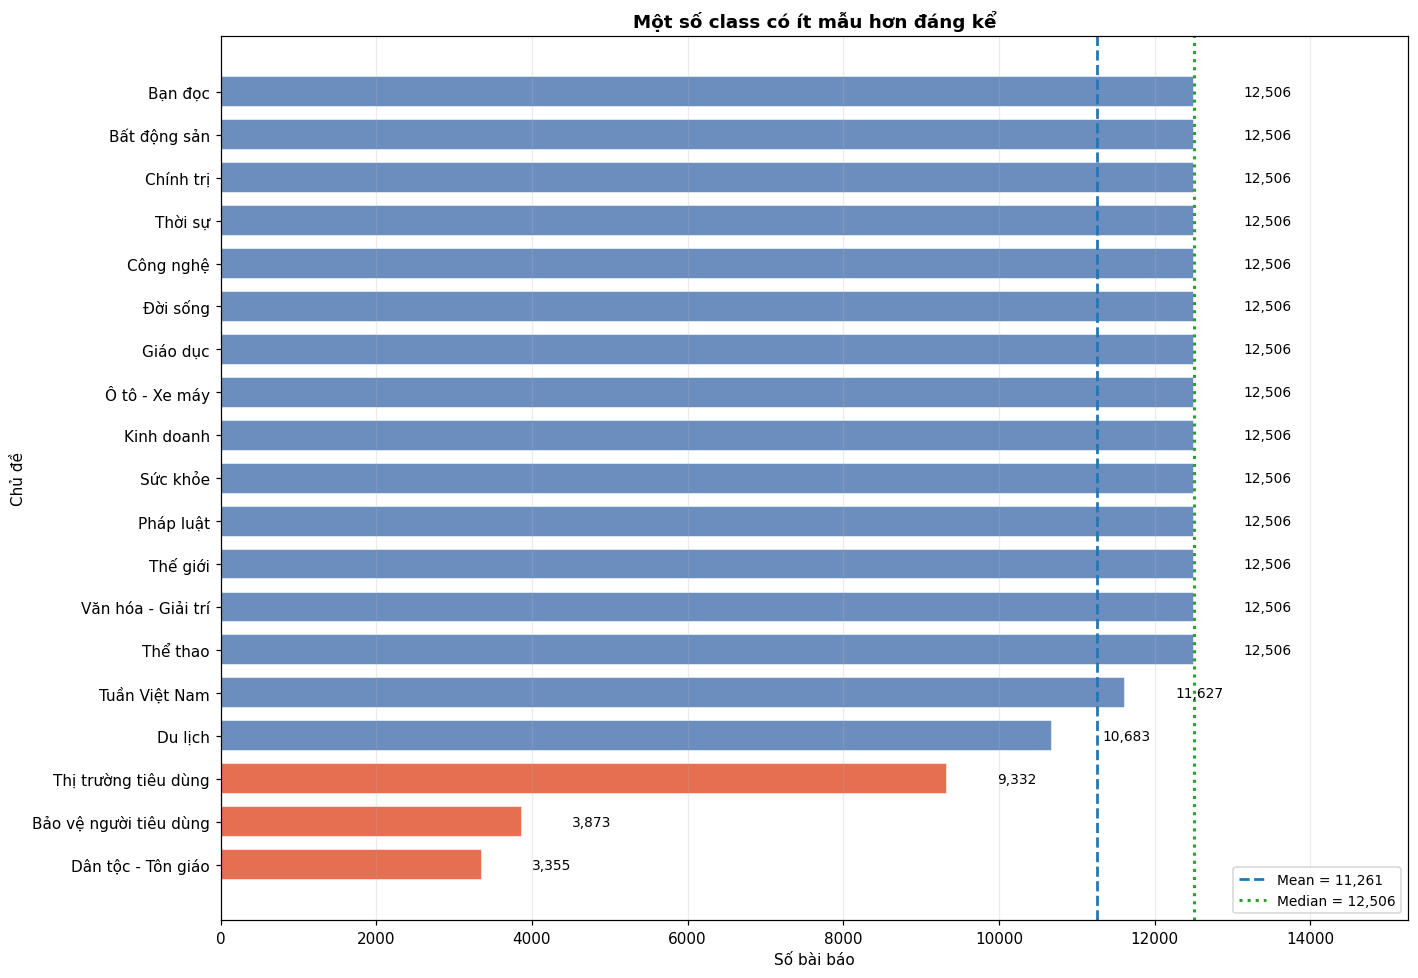

  Nhiều nhất : Bạn đọc                               12,506
  Ít nhất    : Dân tộc - Tôn giáo                     3,355
  Imbalance  : 3.73x


In [5]:
# -- 2.1 Phan bo class ----------------------------------------------------------
_vc = df_raw["label"].value_counts().sort_values(ascending=False)
_total = int(_vc.sum())
_mean = float(_vc.mean())
_median = float(_vc.median())
_warn_thr = _median * 0.75

_colors = ["#e76f51" if v < _warn_thr else "#6c8ebf" for v in _vc.values]

fig, ax = plt.subplots(figsize=(13, 9))
_bars = ax.barh(_vc.index, _vc.values, color=_colors, edgecolor="white", height=0.72)
ax.invert_yaxis()

if len(_vc) <= 25:
    for bar, n in zip(_bars, _vc.values):
        ax.text(bar.get_width() + _total * 0.003,
                bar.get_y() + bar.get_height()/2,
                f"{n:,}", va="center", fontsize=9)

ax.axvline(_mean, color="#1f77b4", ls="--", lw=1.8, label=f"Mean = {_mean:,.0f}")
ax.axvline(_median, color="#2ca02c", ls=":", lw=2.0, label=f"Median = {_median:,.0f}")
ax.set_xlim(0, _vc.max() * 1.22)
ax.set_xlabel("Số bài báo")
ax.set_ylabel("Chủ đề")
ax.set_title("Một số class có ít mẫu hơn đáng kể", fontweight="bold")
ax.grid(axis="x", alpha=0.25)
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout()
save_fig(fig, "01_class_distribution.png")

_ir = _vc.max() / _vc.min()
print(f"  Nhiều nhất : {_vc.idxmax():<35} {_vc.max():>8,}")
print(f"  Ít nhất    : {_vc.idxmin():<35} {_vc.min():>8,}")
print(f"  Imbalance  : {_ir:.2f}x")


[12:56:49][  34.7s] >> Đã lưu -> c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\results\02_text_length.png


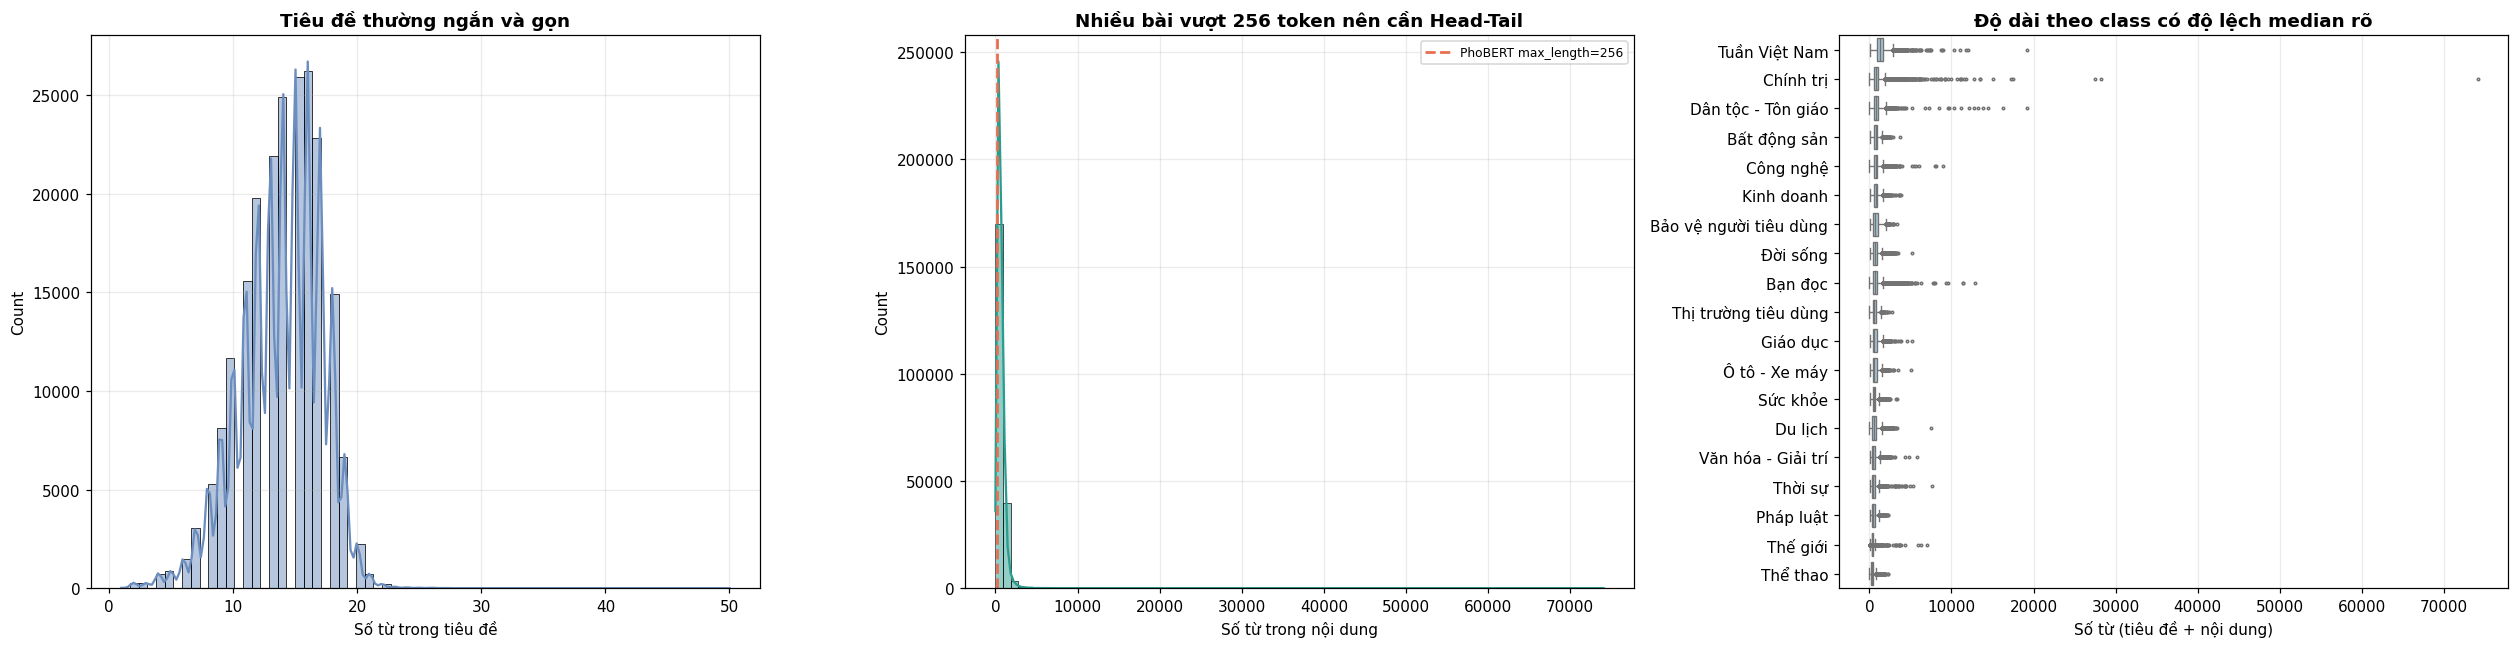

  p50 : 586.0
  p90 : 1,162.7
  p95 : 1,427.0
  max : 74,090.0
  Tren 256 tu: 88.6%


In [6]:
# -- 2.2 Độ dài văn bản ---------------------------------------------------------
_title_len = df_raw["title"].fillna("").astype(str).str.split().str.len()
_content_len = df_raw["content"].fillna("").astype(str).str.split().str.len()
_lens = df_raw["text_len"]

fig, axes = plt.subplots(1, 3, figsize=(23, 6))

sns.histplot(_title_len, bins=70, kde=True, color="#6c8ebf", ax=axes[0])
axes[0].set_title("Tiêu đề thường ngắn và gọn", fontweight="bold")
axes[0].set_xlabel("Số từ trong tiêu đề")
axes[0].grid(alpha=0.25)

sns.histplot(_content_len, bins=80, kde=True, color="#2a9d8f", ax=axes[1])
axes[1].axvline(256, color="#e76f51", ls="--", lw=1.8, label="PhoBERT max_length=256")
axes[1].legend(fontsize=8)
axes[1].set_title("Nhiều bài vượt 256 token nên cần Head-Tail", fontweight="bold")
axes[1].set_xlabel("Số từ trong nội dung")
axes[1].grid(alpha=0.25)

_cls_med = (df_raw.groupby("label")["text_len"].median().sort_values(ascending=False))
_ord = list(_cls_med.index)
sns.boxplot(data=df_raw, y="label", x="text_len", order=_ord, orient="h",
            ax=axes[2], color="#9ecae1", fliersize=1.6, linewidth=0.9)
axes[2].set_title("Độ dài theo class có độ lệch median rõ", fontweight="bold")
axes[2].set_xlabel("Số từ (tiêu đề + nội dung)")
axes[2].set_ylabel("")
axes[2].grid(axis="x", alpha=0.25)

fig.tight_layout()
save_fig(fig, "02_text_length.png")

_trunc_pct = (_lens > 256).mean()
print(f"  p50 : {_lens.quantile(0.50):,.1f}")
print(f"  p90 : {_lens.quantile(0.90):,.1f}")
print(f"  p95 : {_lens.quantile(0.95):,.1f}")
print(f"  max : {_lens.max():,.1f}")
print(f"  Tren 256 tu: {_trunc_pct:.1%}")


In [7]:
# --
_rows = []
for _cls in sorted(df_raw["label"].unique()):
    _sub = df_raw[df_raw["label"] == _cls]["text_len"]
    _rows.append({"Chủ đề": _cls, "Số bài": len(_sub),
                  "Tỷ lệ %": round(len(_sub)/len(df_raw)*100, 2),
                  "TB từ": round(_sub.mean(), 0), "Median từ": round(_sub.median(), 0),
                  "Max từ": int(_sub.max())})
_df_sum = pd.DataFrame(_rows).sort_values("Số bài", ascending=False).reset_index(drop=True)
_df_sum.index += 1
print("BẢNG TỔNG HỢP DỮ LIỆU\n")
display(_df_sum.style
    .background_gradient(subset=["Số bài"], cmap="Blues")
    .background_gradient(subset=["TB từ"], cmap="Greens")
    .format({"Số bài":"{:,}", "Tỷ lệ %":"{:.2f}%", "TB từ":"{:.0f}", "Median từ":"{:.0f}"}))

BẢNG TỔNG HỢP DỮ LIỆU



,Chủ đề,Số bài,Tỷ lệ %,TB từ,Median từ,Max từ
1,Bạn đọc,"12,506",5.85%,689,670,12921
2,Bất động sản,"12,506",5.85%,755,771,3750
3,Chính trị,"12,506",5.85%,957,822,74090
4,Đời sống,"12,506",5.85%,710,687,5131
5,Công nghệ,"12,506",5.85%,788,760,8906
6,Kinh doanh,"12,506",5.85%,779,759,3800
7,Giáo dục,"12,506",5.85%,665,609,5218
8,Pháp luật,"12,506",5.85%,469,391,2323
9,Sức khỏe,"12,506",5.85%,600,573,3350
10,Thể thao,"12,506",5.85%,374,314,2310


---
## Section 3 - Tiền Xử Lý Văn Bản

**Lưu ý PhoBERT**: KHÔNG loại stopwords vì BERT tự học ngữ cảnh.
Chuỗi xử lý: lowercase -> bỏ dấu câu -> bỏ số -> ViTokenizer (tách từ).

- Cell 3.1: tokenize toàn bộ corpus, lưu `temp/processed_data.pkl` *(nặng ~20-40 phút; bỏ qua nếu cache đã có)*
- Cell 3.2: load dữ liệu đã xử lý *(luôn chạy)*

In [8]:
# -- 3.1 Tokenize + lưu cache --------------------------------------------
if os.path.exists(PROCESSED_DATA_PATH):
    print(f"[OK] Cache tồn tại: {PROCESSED_DATA_PATH} - bỏ qua tokenization")
else:
    log("Bắt đầu tiền xử lý văn bản...")

    _df_proc = df_raw[["label"]].copy()
    _df_proc["full_text"] = (df_raw["title"]
                             + " " + df_raw["content"])
    _df_proc = _df_proc[_df_proc["full_text"].str.strip() != ""].reset_index(drop=True)
    log(f"Văn bản hợp lệ: {len(_df_proc):,}", "OK")

    def _clean_one(text):
        '''ViTokenize không có stopwords (PhoBERT tự học context).'''
        from pyvi import ViTokenizer
        import re
        if not isinstance(text, str): return ""
        text = text.lower()
        text = re.sub(r"[^\w\s]", " ", text)
        text = re.sub(r"\d+",     " ", text)
        text = ViTokenizer.tokenize(text)
        return re.sub(r"\s+", " ", text).strip()

    from joblib import Parallel, delayed
    from multiprocessing import cpu_count
    log(f"Tokenize song song {len(_df_proc):,} bài | {cpu_count()} nhân CPU...")
    _df_proc["clean_text"] = Parallel(n_jobs=-1, backend="loky", verbose=1)(
        delayed(_clean_one)(t) for t in _df_proc["full_text"].tolist()
    )
    _df_proc = _df_proc[_df_proc["clean_text"].str.strip() != ""].reset_index(drop=True)
    log(f"Sau tokenization: {len(_df_proc):,} bài", "OK")

    _classes  = sorted(_df_proc["label"].unique().tolist())
    _label2id = {l: i for i, l in enumerate(_classes)}
    _id2label = {i: l for l, i in _label2id.items()}
    _df_proc["label_id"] = _df_proc["label"].map(_label2id)

    with timer("Lưu processed_data.pkl"):
        with open(PROCESSED_DATA_PATH, "wb") as _f:
            pickle.dump({"df":_df_proc, "label2id":_label2id, "id2label":_id2label}, _f)
    log(f"Đã lưu ({os.path.getsize(PROCESSED_DATA_PATH)/1e6:.1f} MB)", "SAVE")

[12:56:49][  35.2s] i Bắt đầu tiền xử lý văn bản...
[12:56:50][  35.7s] OK Văn bản hợp lệ: 213,954
[12:56:50][  35.7s] i Tokenize song song 213,954 bài | 24 nhân CPU...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done 2664 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 8264 tasks      | elapsed:    8.5s
[Parallel(n_jobs=-1)]: Done 15464 tasks      | elapsed:   15.8s
[Parallel(n_jobs=-1)]: Done 24264 tasks      | elapsed:   25.0s
[Parallel(n_jobs=-1)]: Done 34664 tasks      | elapsed:   38.3s
[Parallel(n_jobs=-1)]: Done 41080 tasks      | elapsed:   47.3s
[Parallel(n_jobs=-1)]: Done 47880 tasks      | elapsed:   55.4s
[Parallel(n_jobs=-1)]: Done 55480 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 63880 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 73080 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 85976 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 107576 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 1307

[13:00:35][ 260.6s] OK Sau tokenization: 213,954 bài
[13:00:37][ 263.5s] OK Lưu processed_data.pkl - 2.9s
[13:00:37][ 263.5s] >> Đã lưu (1716.5 MB)


In [9]:
# -- 3.2 Load processed data ---------------------------------------------
with timer("Tải processed_data.pkl"):
    with open(PROCESSED_DATA_PATH, "rb") as f:
        _s = pickle.load(f)

df       = _s["df"]
label2id = _s["label2id"]
id2label = _s["id2label"]
classes  = sorted(df["label"].unique().tolist())
N_CLASSES = len(classes)

_vc3 = df["label"].value_counts()
print(f"[OK] Processed data: {len(df):,} bài | {N_CLASSES} chủ đề\n")
print(f"   {'Chủ đề':<38}  {'Bài':>8}  {'%':>5}  TB tokens (ViTokenizer)")
print(f"   {'-'*62}")
for _cls in classes:
    _n   = _vc3.get(_cls, 0)
    _tl  = df[df["label"]==_cls]["clean_text"].str.split().str.len().mean()
    print(f"   {_cls:<38}  {_n:>8,}  {_n/len(df)*100:>4.1f}%  {_tl:>6.0f}")

[13:00:43][ 269.6s] OK Tải processed_data.pkl - 6.0s
[OK] Processed data: 213,954 bài | 19 chủ đề

   Chủ đề                                       Bài      %  TB tokens (ViTokenizer)
   --------------------------------------------------------------
   Bạn đọc                                   12,506   5.8%     544
   Bảo vệ người tiêu dùng                     3,873   1.8%     588
   Bất động sản                              12,506   5.8%     551
   Chính trị                                 12,506   5.8%     644
   Công nghệ                                 12,506   5.8%     566
   Du lịch                                   10,683   5.0%     476
   Dân tộc - Tôn giáo                         3,355   1.6%     647
   Giáo dục                                  12,506   5.8%     487
   Kinh doanh                                12,506   5.8%     564
   Pháp luật                                 12,506   5.8%     352
   Sức khỏe                                  12,506   5.8%     444
   Thế giới   

---
## Section 4 - Tokenize Head-Tail + Chia Train/Test

**Chiến lược Head-Tail**: lấy 127 token đầu + 127 token cuối để tạo tổng 256 token (bao gồm [CLS] và [SEP]).
Hiệu quả khi bài báo dài, giữ được thông tin cả phần mở bài lẫn kết luận.

In [10]:
# --
class HeadTailDataset(TorchDataset):
    '''Head+Tail: 127 token đầu + 127 token cuối (+ [CLS] + [SEP] = 256).'''
    def __init__(self, texts, labels, tokenizer, label2id):
        self.labels     = [label2id[l] for l in labels]
        self.input_ids  = []
        self.attn_masks = []
        half   = (MAX_LENGTH - 2) // 2
        cls_id = tokenizer.cls_token_id
        sep_id = tokenizer.sep_token_id
        pad_id = tokenizer.pad_token_id

        for text in tqdm(texts.tolist(), desc="  HeadTail tokenize", ncols=80, leave=True):
            tokens = tokenizer.encode(text, add_special_tokens=False, truncation=False)
            if len(tokens) <= MAX_LENGTH - 2:
                enc  = tokenizer(text, truncation=True, padding="max_length", max_length=MAX_LENGTH)
                ids  = enc["input_ids"]
                attn = enc["attention_mask"]
            else:
                head  = tokens[:half]
                tail  = tokens[-half:]
                ids   = [cls_id] + head + tail + [sep_id]
                attn  = [1] * len(ids)
                pad_n = MAX_LENGTH - len(ids)
                ids  += [pad_id] * pad_n
                attn += [0]     * pad_n
            self.input_ids.append(ids)
            self.attn_masks.append(attn)

        # Chuyển list -> stacked tensors ngay sau tokenize
        # __getitem__ chỉ cần tensor indexing, không tạo tensor mới mỗi sample
        self._to_tensors()

    def _to_tensors(self):
        '''Chuyển Python lists -> stacked tensors. Gọi sau khi load cache cũ format.'''
        if isinstance(self.input_ids, list):
            self.input_ids  = torch.tensor(self.input_ids,  dtype=torch.long)
            self.attn_masks = torch.tensor(self.attn_masks, dtype=torch.long)
            self.labels     = torch.tensor(self.labels,     dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            "input_ids":      self.input_ids[idx],
            "attention_mask": self.attn_masks[idx],
            "labels":         self.labels[idx],
        }


class WeightedTrainer(Trainer):
    '''Trainer với weighted cross-entropy để xử lý mất cân bằng class.'''
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        weight  = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss    = torch.nn.functional.cross_entropy(logits, labels, weight=weight)
        return (loss, outputs) if return_outputs else loss


class EpochCallback(TrainerCallback):
    '''Log chi tiết sau mỗi epoch + thời gian thực mỗi logging_steps.'''
    def __init__(self):
        self._train_start  = None
        self._epoch_start  = None
        self._total_steps  = None

    def on_train_begin(self, args, state, control, **kwargs):
        self._train_start = time.time()
        self._total_steps = state.max_steps
        log(f"Tổng steps: {self._total_steps:,}  |  {NUM_EPOCHS} epochs  |  "
            f"~{self._total_steps//NUM_EPOCHS:,} steps/epoch", "OK")

    def on_epoch_begin(self, args, state, control, **kwargs):
        self._epoch_start = time.time()
        ep = int(state.epoch) + 1
        elapsed = time.time() - self._train_start if self._train_start else 0
        log(f"{'-'*50}")
        log(f"EPOCH {ep}/{NUM_EPOCHS} - bắt đầu  |  Đã chạy: {elapsed/60:.1f} phút")
        gpu_status()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or "loss" not in logs: return
        step    = state.global_step
        total   = self._total_steps or 1
        elapsed = time.time() - self._train_start if self._train_start else 0
        eta_sec = (elapsed / step * (total - step)) if step > 0 else 0
        spd     = logs.get("train_samples_per_second", 0)
        spd_str = f"  |  {spd:.0f} samples/s" if spd else ""
        log(f"step {step:>5}/{total}  [{step/total*100:4.1f}%]  "
            f"loss={logs['loss']:.4f}  lr={logs.get('learning_rate',0):.2e}  "
            f"elapsed={elapsed/60:.1f}m  ETA={eta_sec/60:.1f}m{spd_str}")

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        acc   = metrics.get("eval_accuracy",    0)
        f1_w  = metrics.get("eval_f1_weighted", 0)
        f1_m  = metrics.get("eval_f1_macro",    0)
        eloss = metrics.get("eval_loss",        0)
        ep_t  = time.time() - self._epoch_start if self._epoch_start else 0
        total_t = time.time() - self._train_start if self._train_start else 0
        log(f"EPOCH {state.epoch:.0f} DONE  |  Loss={eloss:.4f}  Acc={acc:.4f}  "
            f"F1-w={f1_w:.4f}  F1-m={f1_m:.4f}  "
            f"(epoch {ep_t/60:.1f}m  /  tổng {total_t/60:.1f}m)", "OK")

print("[OK] Dataset classes và WeightedTrainer đã định nghĩa xong.")

[OK] Dataset classes và WeightedTrainer đã định nghĩa xong.


In [11]:
# --
log("Chia train/test (stratified)...")
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df["clean_text"], df["label"],
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df["label"]
)
log(f"Train: {len(X_train_raw):,}  |  Test: {len(X_test_raw):,}", "OK")

# Tải tokenizer PhoBERT
log(f"Tải tokenizer: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# --
_sample_text = df["clean_text"].sample(min(1000, len(df)), random_state=RANDOM_STATE).tolist()
_tlen = np.array([len(tokenizer.encode(t, truncation=False)) for t in
                  tqdm(_sample_text, desc="  Token length check", ncols=80)])
log(f"Token length - mean={_tlen.mean():.1f} | median={np.median(_tlen):.1f} | "
    f"max={_tlen.max()} | >256: {(_tlen>256).mean():.1%}", "OK")

# Tính class weights
log("Tính class weights (balanced + manual boost)...")
_cw_vals = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(N_CLASSES),
    y=[label2id[l] for l in y_train],
)
for i, cls in enumerate(classes):
    _cw_vals[i] *= MANUAL_CLASS_BOOST.get(cls, 1.0)
class_weights = torch.tensor(_cw_vals, dtype=torch.float32)
print(f"\n   {'Chủ đề':<38}  {'Weight':>8}  {'Boost':>8}")
print(f"   {'-'*60}")
for i, cls in enumerate(classes):
    _boost = MANUAL_CLASS_BOOST.get(cls, 1.0)
    print(f"   {cls:<38}  {_cw_vals[i]:>8.4f}  {_boost:>8.2f}")

# --
_HT_TRAIN_CACHE = os.path.join(TEMP_DIR, "headtail_train.pkl")
_HT_TEST_CACHE  = os.path.join(TEMP_DIR, "headtail_test.pkl")

if os.path.exists(_HT_TRAIN_CACHE) and os.path.exists(_HT_TEST_CACHE):
    log("Tải HeadTail datasets từ cache...", "OK")
    with timer("Tải cache train"):
        with open(_HT_TRAIN_CACHE, "rb") as f:
            train_dataset = pickle.load(f)
    with timer("Tải cache test"):
        with open(_HT_TEST_CACHE, "rb") as f:
            test_dataset = pickle.load(f)
    # Cache cũ lưu lists -> chuyển sang stacked tensors để __getitem__ nhanh hơn
    train_dataset._to_tensors()
    test_dataset._to_tensors()
    log("Đã tải HeadTail datasets t? cache", "OK")
else:
    log("Tạo HeadTail train dataset (lần đầu - sẽ cache lại)...")
    with timer("Tạo HeadTail train"):
        train_dataset = HeadTailDataset(X_train_raw, y_train, tokenizer, label2id)
    with timer("Lưu train cache"):
        with open(_HT_TRAIN_CACHE, "wb") as f:
            pickle.dump(train_dataset, f)
    log(f"Đã lưu cache train ({os.path.getsize(_HT_TRAIN_CACHE)/1e6:.0f} MB)", "SAVE")

    log("Tạo HeadTail test dataset...")
    with timer("Test HeadTail"):
        test_dataset = HeadTailDataset(X_test_raw, y_test, tokenizer, label2id)
    with timer("Lưu test cache"):
        with open(_HT_TEST_CACHE, "wb") as f:
            pickle.dump(test_dataset, f)
    log(f"Đã lưu cache test ({os.path.getsize(_HT_TEST_CACHE)/1e6:.0f} MB)", "SAVE")

log(f"Train: {len(train_dataset):,} mẫu  |  Test: {len(test_dataset):,} mẫu", "OK")
log(f"Kích thước input_ids: {train_dataset.input_ids.shape}  dtype={train_dataset.input_ids.dtype}", "OK")
log(f"[SAVE] Xóa cache khi không cần: {_HT_TRAIN_CACHE}", "INFO")
gpu_status()

[13:00:53][ 279.1s] i Chia train/test (stratified)...
[13:00:53][ 279.2s] OK Train: 181,860  |  Test: 32,094
[13:00:53][ 279.2s] i Tải tokenizer: vinai/phobert-base-v2...


  Token length check: 100%|████████████████| 1000/1000 [00:02<00:00, 462.59it/s]

[13:00:58][ 283.6s] OK Token length - mean=577.6 | median=488.0 | max=4545 | >256: 84.3%
[13:00:58][ 283.6s] i Tính class weights (balanced + manual boost)...



   Chủ đề                                    Weight     Boost
   ------------------------------------------------------------
   Bạn đọc                                   0.9004      1.00
   Bảo vệ người tiêu dùng                    2.9075      1.00
   Bất động sản                              0.9004      1.00
   Chính trị                                 0.9004      1.00
   Công nghệ                                 0.9004      1.00
   Du lịch                                   1.0540      1.00
   Dân tộc - Tôn giáo                        4.5307      1.35
   Giáo dục                                  0.9004      1.00
   Kinh doanh                                1.0355      1.15
   Pháp luật                                 0.9004      1.00
   Sức khỏe                                  0.9004      1.00
   Thế giới                                  0.9004      1.00
   Thể thao                                  0.9004      1.00
   Thị trường tiêu dùng                      1.3274      1.10
   Th

  HeadTail tokenize: 100%|█████████████| 181860/181860 [07:14<00:00, 418.80it/s]


[13:08:15][ 721.4s] OK Tạo HeadTail train - 437.8s
[13:08:16][ 722.2s] OK Lưu train cache - 0.8s
[13:08:16][ 722.2s] >> Đã lưu cache train (746 MB)
[13:08:16][ 722.2s] i Tạo HeadTail test dataset...


  HeadTail tokenize: 100%|███████████████| 32094/32094 [00:59<00:00, 540.51it/s]


[13:09:16][ 782.3s] OK Test HeadTail - 60.0s
[13:09:16][ 782.4s] OK Lưu test cache - 0.1s
[13:09:16][ 782.4s] >> Đã lưu cache test (132 MB)
[13:09:16][ 782.4s] OK Train: 181,860 mẫu  |  Test: 32,094 mẫu
[13:09:16][ 782.4s] OK Kích thước input_ids: torch.Size([181860, 256])  dtype=torch.int64
[13:09:16][ 782.4s] i [SAVE] Xóa cache khi không cần: c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\temp\headtail_train.pkl
[13:09:16][ 782.4s] GPU VRAM: 0.0GB đã dùng / 0.0GB dự trữ / 12.0GB còn trống


---
## Section 5 - Huấn Luyện Mô Hình

**PhoBERT Base v2** fine-tuning với Hugging Face Trainer.

| Tham số | Giá trị | Lý do |
|---------|---------|-------|
| `LR` | 2e-5 | Tránh catastrophic forgetting với pretrained model |
| `batch` | 32 - accum 2 = eff 64 | Phù hợp GPU 12GB, vẫn giữ effective batch 64 |
| `class_weight` | balanced | Dataset m?t cón b?ng |
| `BF16` | True | RTX A3000 (compute 8.6) hỗ trợ BF16 |
| `metric_for_best_model` | f1_macro | Ưu tiên các class ít mẫu hơn weighted F1 |

- Cell 5.1: training *(bỏ qua nếu `model/config.json` đã tồn tại)*
- Cell 5.2: load kết quả *(luôn chạy)*

In [12]:
# -- 5.1 Huấn luyện PhoBERT + lưu model ---------------------------------
_MODEL_READY = os.path.exists(os.path.join(MODEL_DIR, "config.json"))
_CKPT_DIR    = os.path.join(TEMP_DIR, "checkpoints")

if _MODEL_READY:
    log(f"Model đã tồn tại: {MODEL_DIR} - bỏ qua training", "OK")
else:
    torch.cuda.empty_cache()
    log(f"Tải mô hình PhoBERT: {MODEL_NAME}...")

    def make_compute_metrics():
        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds = np.argmax(logits, axis=1)
            return {
                "accuracy":    accuracy_score(labels, preds),
                "f1_weighted": f1_score(labels, preds, average="weighted"),
                "f1_macro":    f1_score(labels, preds, average="macro"),
            }
        return compute_metrics

    model_train = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=N_CLASSES,
        id2label=id2label, label2id=label2id,
        ignore_mismatched_sizes=True,
    ).to(device)

    # Fix LayerNorm beta/gamma (PhoBERT checkpoint cÅ©)
    _sd = model_train.state_dict()
    _new_sd = {}
    for k, v in _sd.items():
        if k.endswith(".beta"):    _new_sd[k.replace(".beta",  ".bias")]   = v
        elif k.endswith(".gamma"): _new_sd[k.replace(".gamma", ".weight")] = v
        else:                      _new_sd[k] = v
    model_train.load_state_dict(_new_sd, strict=False)

    log(f"Tham số: {sum(p.numel() for p in model_train.parameters())/1e6:.1f}M", "OK")
    gpu_status()

    training_args = TrainingArguments(
        output_dir=_CKPT_DIR,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,       # 64
        per_device_eval_batch_size=EVAL_BATCH,        # 128
        gradient_accumulation_steps=GRAD_ACCUM,       # 1
        learning_rate=LR,
        weight_decay=WEIGHT_DECAY,
        warmup_steps=WARMUP_STEPS,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        bf16=BF16,
        logging_steps=100,
        save_total_limit=1,
        report_to="none",
        # num_workers=0: bắt buộc trên Windows (Python 3.14 spawn multiprocessing
        # crash với large tensors trong worker). Dataset đã dùng stacked tensors
        # nên __getitem__ rất nhanh - bottleneck là GPU chứ không phải CPU.
        dataloader_num_workers=0,
        dataloader_pin_memory=True,
        gradient_checkpointing=False,                 # OFF - đủ cho base-v2 trên 12GB
        optim="adamw_torch_fused",                    # ~15% nhanh hÆ¡n optimizer step
        torch_compile=False,                          # Python 3.14+ chưa hỗ trợ
    )

    trainer = WeightedTrainer(
        model=model_train,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=make_compute_metrics(),
        class_weights=class_weights,
        callbacks=[
            EarlyStoppingCallback(early_stopping_patience=3),
            EpochCallback(),
        ],
    )

    log("Bắt đầu fine-tuning PhoBERT...")
    _t_start = time.time()
    trainer.train()
    _train_time = time.time() - _t_start
    log(f"Huấn luyện xong - {_train_time:.0f}s ({_train_time/60:.1f} phút)", "OK")
    gpu_status()

    # Lưu model + tokenizer
    trainer.save_model(MODEL_DIR)
    tokenizer.save_pretrained(MODEL_DIR)
    log(f"Đã lưu mô hình: {MODEL_DIR}", "SAVE")

    # Lưu training history
    with open(TRAIN_HISTORY_PATH, "wb") as f:
        pickle.dump({"log_history": trainer.state.log_history,
                     "train_time_sec": _train_time}, f)
    log(f"Đã lưu l?<ch s? hu?n luy??n: {TRAIN_HISTORY_PATH}", "SAVE")

    # Dọn checkpoints
    if os.path.exists(_CKPT_DIR):
        shutil.rmtree(_CKPT_DIR)
    del model_train, trainer
    torch.cuda.empty_cache()
    log("VRAM đã giải phóng", "OK")

[13:09:16][ 782.4s] i Tải mô hình PhoBERT: vinai/phobert-base-v2...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 55321.23it/s]
RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[13:09:18][ 784.1s] OK Tham số: 135.0M
[13:09:18][ 784.1s] GPU VRAM: 0.5GB đã dùng / 0.6GB dự trữ / 11.4GB còn trống
[13:09:18][ 784.3s] i Bắt đầu fine-tuning PhoBERT...
[13:09:18][ 784.5s] OK Tổng steps: 19,894  |  7 epochs  |  ~2,842 steps/epoch
[13:09:18][ 784.5s] i --------------------------------------------------
[13:09:18][ 784.5s] i EPOCH 1/7 - bắt đầu  |  Đã chạy: 0.0 phút
[13:09:18][ 784.5s] GPU VRAM: 0.5GB đã dùng / 0.6GB dự trữ / 11.4GB còn trống


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.842822,0.393080,0.884028,0.885066,0.874004
2,0.592447,0.338727,0.898610,0.898742,0.890239
3,0.450716,0.369929,0.898860,0.899175,0.888960
4,0.339738,0.353477,0.908830,0.909145,0.901806
5,0.251627,0.367065,0.908893,0.908854,0.901859
6,0.177052,0.404519,0.908114,0.908387,0.901121
7,0.150276,0.413172,0.909921,0.909975,0.902562


[13:10:31][ 857.2s] i step   100/19894  [ 0.5%]  loss=5.6934  lr=9.90e-06  elapsed=1.2m  ETA=240.0m
[13:11:45][ 930.6s] i step   200/19894  [ 1.0%]  loss=4.3533  lr=1.99e-05  elapsed=2.4m  ETA=239.8m
[13:12:59][1004.7s] i step   300/19894  [ 1.5%]  loss=3.0299  lr=1.99e-05  elapsed=3.7m  ETA=239.8m
[13:14:13][1079.4s] i step   400/19894  [ 2.0%]  loss=2.3883  lr=1.98e-05  elapsed=4.9m  ETA=239.5m
[13:15:28][1154.4s] i step   500/19894  [ 2.5%]  loss=2.0624  lr=1.97e-05  elapsed=6.2m  ETA=239.2m
[13:16:43][1229.5s] i step   600/19894  [ 3.0%]  loss=1.7715  lr=1.96e-05  elapsed=7.4m  ETA=238.5m
[13:17:59][1304.8s] i step   700/19894  [ 3.5%]  loss=1.5709  lr=1.95e-05  elapsed=8.7m  ETA=237.8m
[13:19:14][1380.1s] i step   800/19894  [ 4.0%]  loss=1.4180  lr=1.94e-05  elapsed=9.9m  ETA=236.9m
[13:20:29][1455.5s] i step   900/19894  [ 4.5%]  loss=1.3407  lr=1.93e-05  elapsed=11.2m  ETA=236.0m
[13:21:45][1531.1s] i step  1000/19894  [ 5.0%]  loss=1.2605  lr=1.92e-05  elapsed=12.4m  ETA=235.1

...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.18it/s]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

[17:40:43][17069.1s] OK Huấn luyện xong - 16285s (271.4 phút)
[17:40:43][17069.1s] GPU VRAM: 1.5GB đã dùng / 5.7GB dự trữ / 6.3GB còn trống


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.00it/s]

[17:40:44][17069.6s] >> Đã lưu mô hình: c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\model
[17:40:44][17069.6s] >> Đã lưu l?<ch s? hu?n luy??n: c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\model\train_history.pkl


[17:40:44][17069.8s] OK VRAM đã giải phóng


In [13]:
# -- 5.2 Load model + dự đoán tập test ----------------------------------
log(f"Tải mô hình từ {MODEL_DIR}...")
model_eval = AutoModelForSequenceClassification.from_pretrained(
    MODEL_DIR,
    num_labels=N_CLASSES,
    id2label=id2label,
    label2id=label2id,
).to(device)
model_eval.eval()

def make_compute_metrics():
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=1)
        return {"accuracy":    accuracy_score(labels, preds),
                "f1_weighted": f1_score(labels, preds, average="weighted"),
                "f1_macro":    f1_score(labels, preds, average="macro")}
    return compute_metrics

_eval_args = TrainingArguments(
    output_dir=TEMP_DIR, per_device_eval_batch_size=EVAL_BATCH,
    bf16=BF16, report_to="none",
    dataloader_num_workers=0,       # Windows: spawn multiprocessing crash với num_workers>0
    dataloader_pin_memory=True,
)
_eval_trainer = Trainer(
    model=model_eval, args=_eval_args,
    eval_dataset=test_dataset, compute_metrics=make_compute_metrics(),
)

log("Dự đoán trên tập test...")
with timer("Inference"):
    _raw = _eval_trainer.predict(test_dataset)

y_pred_ids  = np.argmax(_raw.predictions, axis=1).tolist()
y_true_ids  = [label2id[l] for l in y_test]
raw_logits  = _raw.predictions

model_acc   = accuracy_score(y_true_ids, y_pred_ids)
model_f1w   = f1_score(y_true_ids, y_pred_ids, average="weighted")
model_f1m   = f1_score(y_true_ids, y_pred_ids, average="macro")
f1_per_class= dict(zip(classes, f1_score(y_true_ids, y_pred_ids,
                                          labels=list(range(N_CLASSES)), average=None)))

# Load training history nếu có
log_history = []
train_time_sec = 0
if os.path.exists(TRAIN_HISTORY_PATH):
    with open(TRAIN_HISTORY_PATH, "rb") as f:
        _hist = pickle.load(f)
    log_history    = _hist.get("log_history", [])
    train_time_sec = _hist.get("train_time_sec", 0)

print(f"\n{'='*55}")
print(f"  PhoBERT Base v2 - Head-Tail")
print(f"  {'-'*52}")
print(f"  Accuracy   : {model_acc:.4f}  ({model_acc*100:.2f}%)")
print(f"  F1-weighted: {model_f1w:.4f}")
print(f"  F1-macro   : {model_f1m:.4f}")
if train_time_sec:
    print(f"  Train time : {train_time_sec/60:.1f} phút")
print(f"{'='*55}")
gpu_status()

[17:40:44][17069.8s] i Tải mô hình từ c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\model...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7339.47it/s]


[17:40:44][17070.3s] i Dự đoán trên tập test...


[17:42:38][17184.5s] OK Inference - 114.2s

  PhoBERT Base v2 - Head-Tail
  ----------------------------------------------------
  Accuracy   : 0.9099  (90.99%)
  F1-weighted: 0.9100
  F1-macro   : 0.9026
  Train time : 271.4 phút
[17:42:39][17184.6s] GPU VRAM: 1.0GB đã dùng / 1.7GB dự trữ / 10.3GB còn trống


---
## Section 6 - Đánh Giá Mô Hình

Báo cáo phân loại, ma trận nhầm lẫn, F1 theo từng chủ đề và đường cong huấn luyện.

In [14]:
# -- 6.1 Báo cáo phân loại -----------------------------------------------
_report_str = classification_report(y_true_ids, y_pred_ids, target_names=classes, digits=4)

print(f"{'='*65}")
print(f"  BÁO CÁO PHÂN LOẠI - PhoBERT Base v2 Head-Tail")
print(f"  {'-'*62}")
print(f"  Accuracy   : {model_acc:.4f}")
print(f"  F1-weighted: {model_f1w:.4f}")
print(f"  F1-macro   : {model_f1m:.4f}")
print(f"{'='*65}")
print(_report_str)

_rp = os.path.join(RESULTS_DIR, "classification_report.txt")
with open(_rp, "w", encoding="utf-8") as f:
    f.write(f"PhoBERT Base v2 - Head-Tail\n")
    f.write(f"Accuracy:    {model_acc:.4f}\n")
    f.write(f"F1-weighted: {model_f1w:.4f}\n")
    f.write(f"F1-macro:    {model_f1m:.4f}\n\n")
    f.write(_report_str)
log(f"Đã lưu: {_rp}", "SAVE")

  BÁO CÁO PHÂN LOẠI - PhoBERT Base v2 Head-Tail
  --------------------------------------------------------------
  Accuracy   : 0.9099
  F1-weighted: 0.9100
  F1-macro   : 0.9026
                        precision    recall  f1-score   support

               Bạn đọc     0.9596    0.9360    0.9477      1876
Bảo vệ người tiêu dùng     0.8897    0.8468    0.8677       581
          Bất động sản     0.9099    0.9318    0.9207      1876
             Chính trị     0.9009    0.9009    0.9009      1876
             Công nghệ     0.9126    0.9014    0.9069      1876
               Du lịch     0.8781    0.8995    0.8887      1602
    Dân tộc - Tôn giáo     0.7330    0.8569    0.7901       503
              Giáo dục     0.9199    0.9424    0.9310      1876
            Kinh doanh     0.8367    0.8220    0.8293      1876
             Pháp luật     0.9045    0.9041    0.9043      1876
              Sức khỏe     0.9470    0.9435    0.9453      1876
              Thế giới     0.9654    0.9808    0.973

[17:42:40][17185.8s] >> Đã lưu -> c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\results\03_confusion_matrix.png


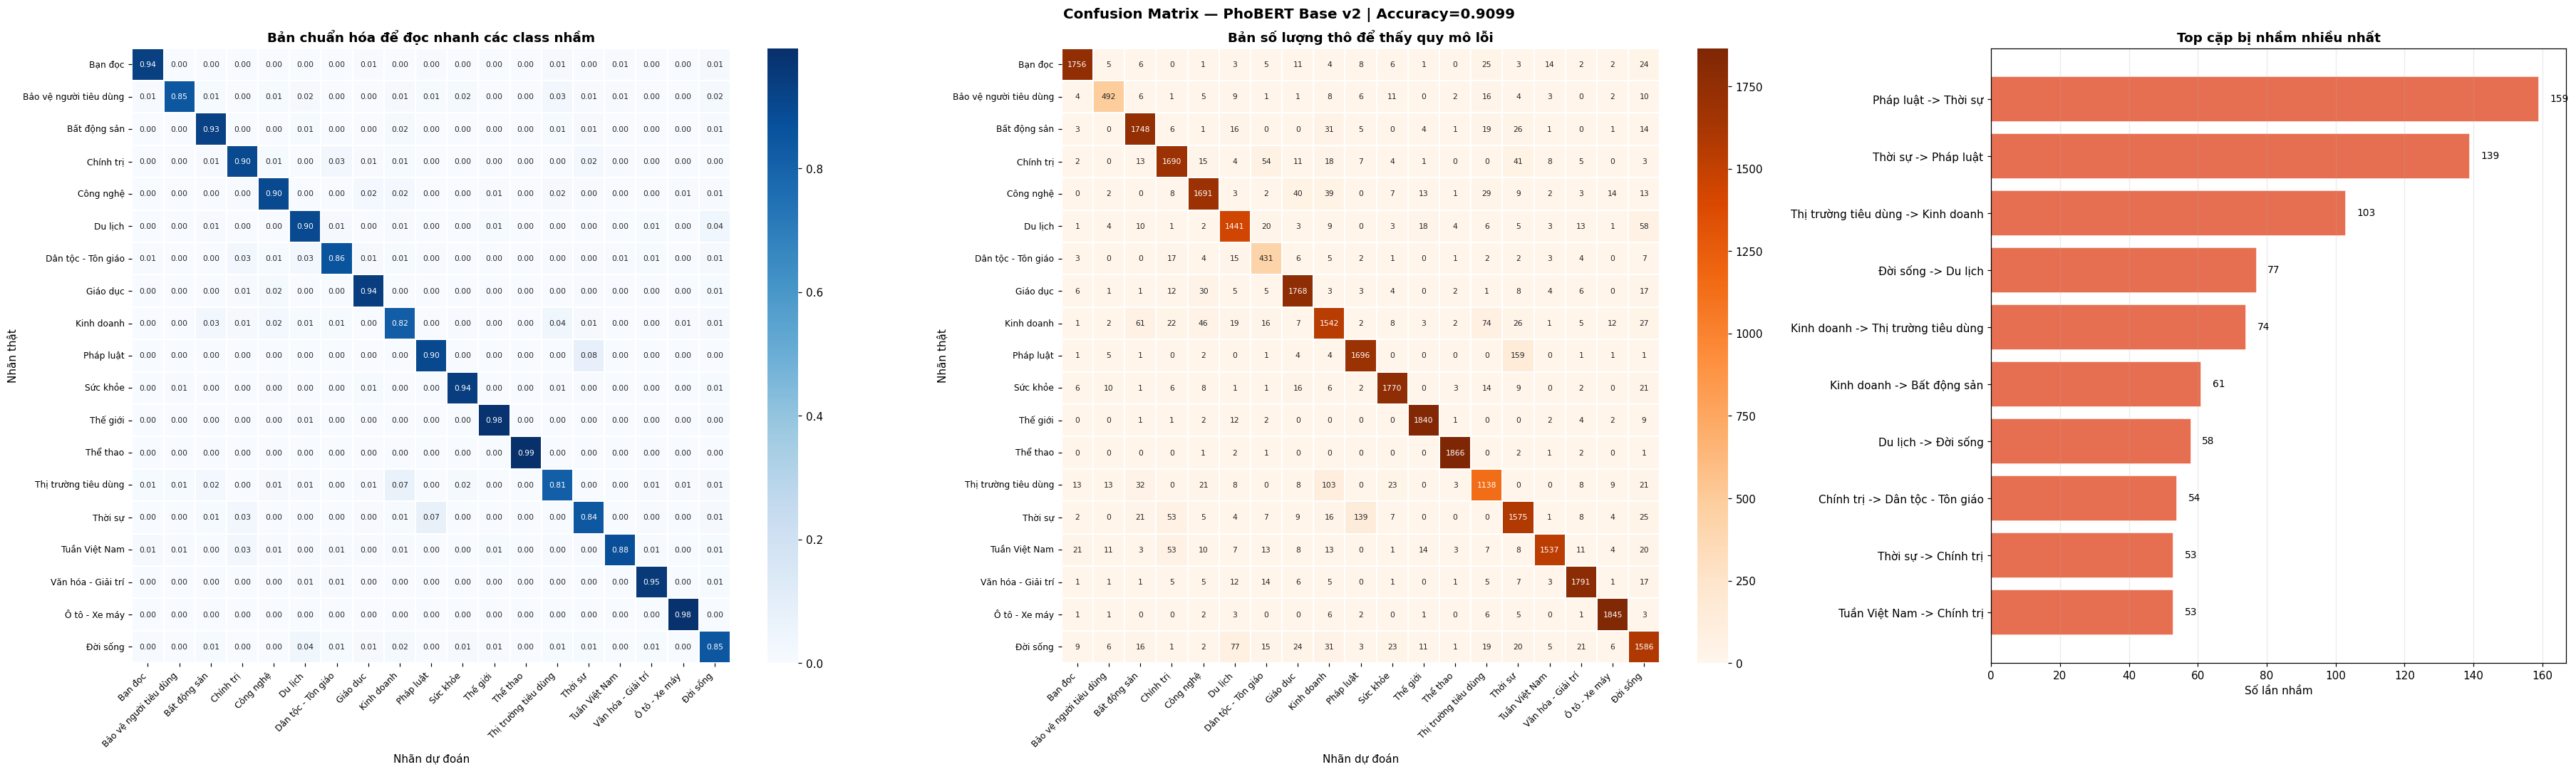

In [15]:
# -- 6.2 Confusion matrix + top confusion pairs --------------------------------
_cm = confusion_matrix(y_true_ids, y_pred_ids, labels=list(range(N_CLASSES)))
_cmn = _cm.astype(float) / np.clip(_cm.sum(axis=1, keepdims=True), 1, None)

_pairs = []
for i, t in enumerate(classes):
    for j, p in enumerate(classes):
        if i == j:
            continue
        c = int(_cm[i, j])
        if c > 0:
            _pairs.append((f"{t} -> {p}", c))
_top_pairs = sorted(_pairs, key=lambda x: x[1], reverse=True)[:10]

fig, axes = plt.subplots(1, 3, figsize=(33, 10), gridspec_kw={"width_ratios": [1.3, 1.3, 1.0]})

sns.heatmap(_cmn, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.25, linecolor="white", ax=axes[0], annot_kws={"size": 7})
axes[0].set_title("Bản chuẩn hóa để đọc nhanh các class nhầm", fontweight="bold")
axes[0].set_xlabel("Nhãn dự đoán")
axes[0].set_ylabel("Nhãn thật")
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.setp(axes[0].get_yticklabels(), rotation=0, fontsize=8)

sns.heatmap(_cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.25, linecolor="white", ax=axes[1], annot_kws={"size": 7})
axes[1].set_title("Bản số lượng thô để thấy quy mô lỗi", fontweight="bold")
axes[1].set_xlabel("Nhãn dự đoán")
axes[1].set_ylabel("Nhãn thật")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right", fontsize=8)
plt.setp(axes[1].get_yticklabels(), rotation=0, fontsize=8)

if _top_pairs:
    _labels = [x[0] for x in _top_pairs][::-1]
    _vals = [x[1] for x in _top_pairs][::-1]
    _bars = axes[2].barh(_labels, _vals, color="#e76f51", edgecolor="white")
    for b, v in zip(_bars, _vals):
        axes[2].text(v + max(_vals) * 0.02, b.get_y() + b.get_height()/2, f"{v}", va="center", fontsize=9)
    axes[2].set_title("Top cặp bị nhầm nhiều nhất", fontweight="bold")
    axes[2].set_xlabel("Số lần nhầm")
    axes[2].grid(axis="x", alpha=0.25)
else:
    axes[2].axis("off")

fig.suptitle(f"Confusion Matrix — PhoBERT Base v2 | Accuracy={model_acc:.4f}", fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "03_confusion_matrix.png")


[17:42:41][17186.7s] >> Đã lưu -> c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\results\04_f1_per_class.png


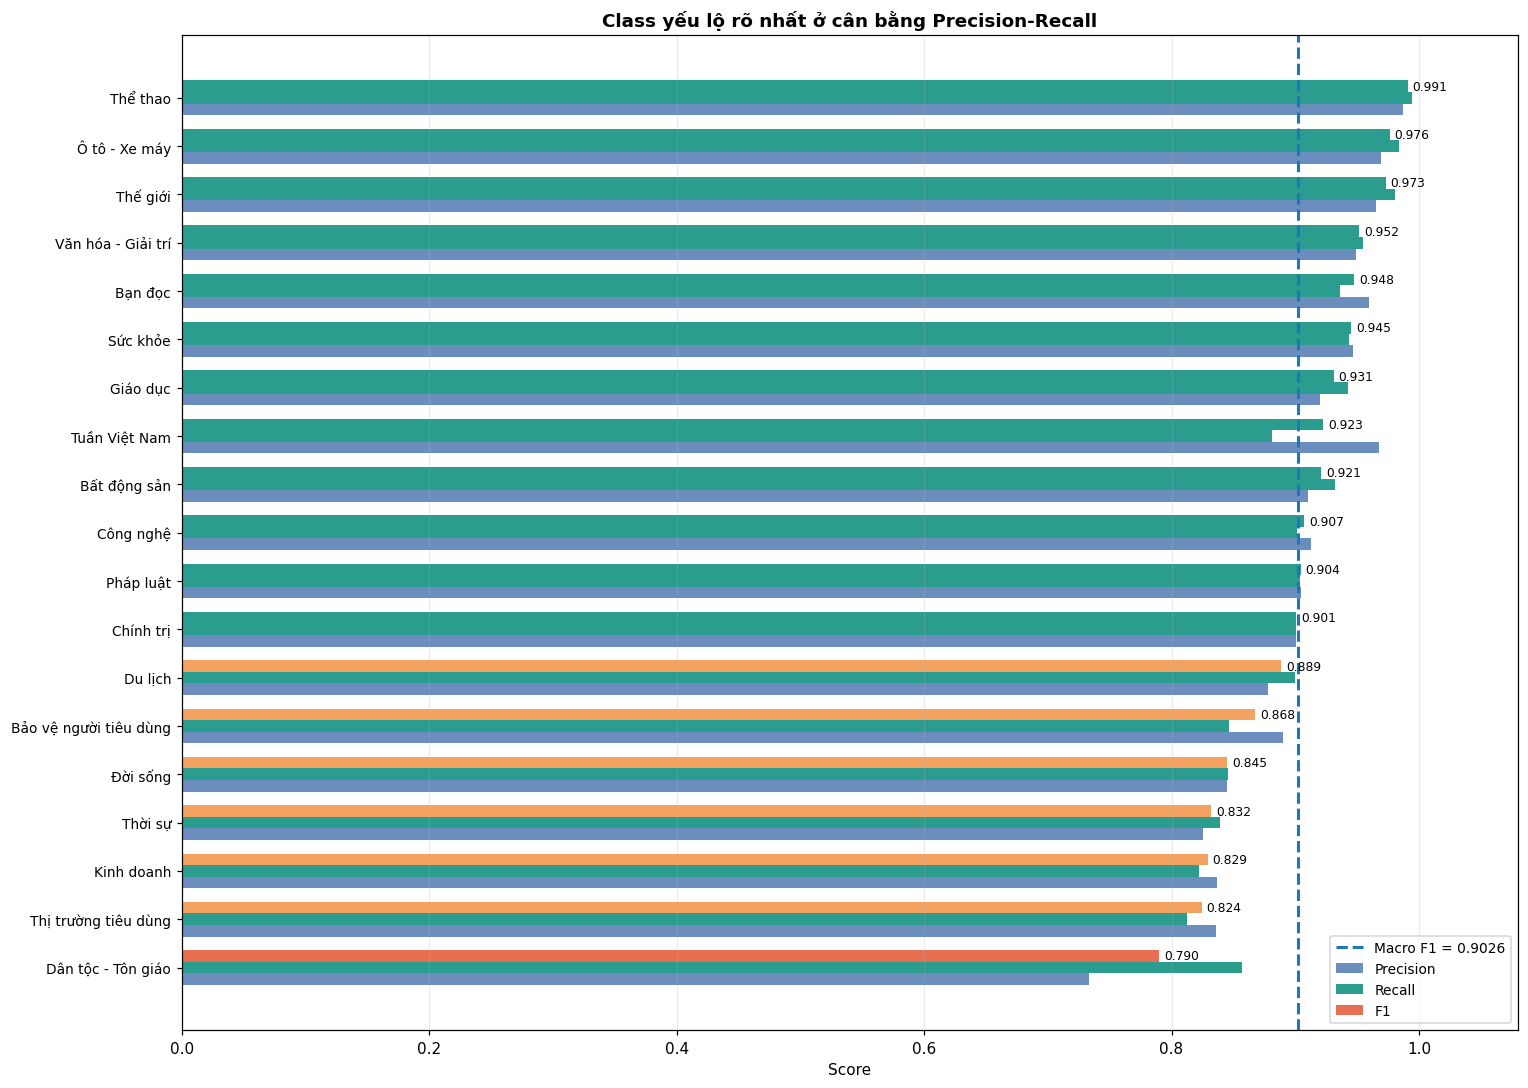

[17:42:41][17186.9s] >> Đã lưu -> c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\results\07_support_vs_f1.png


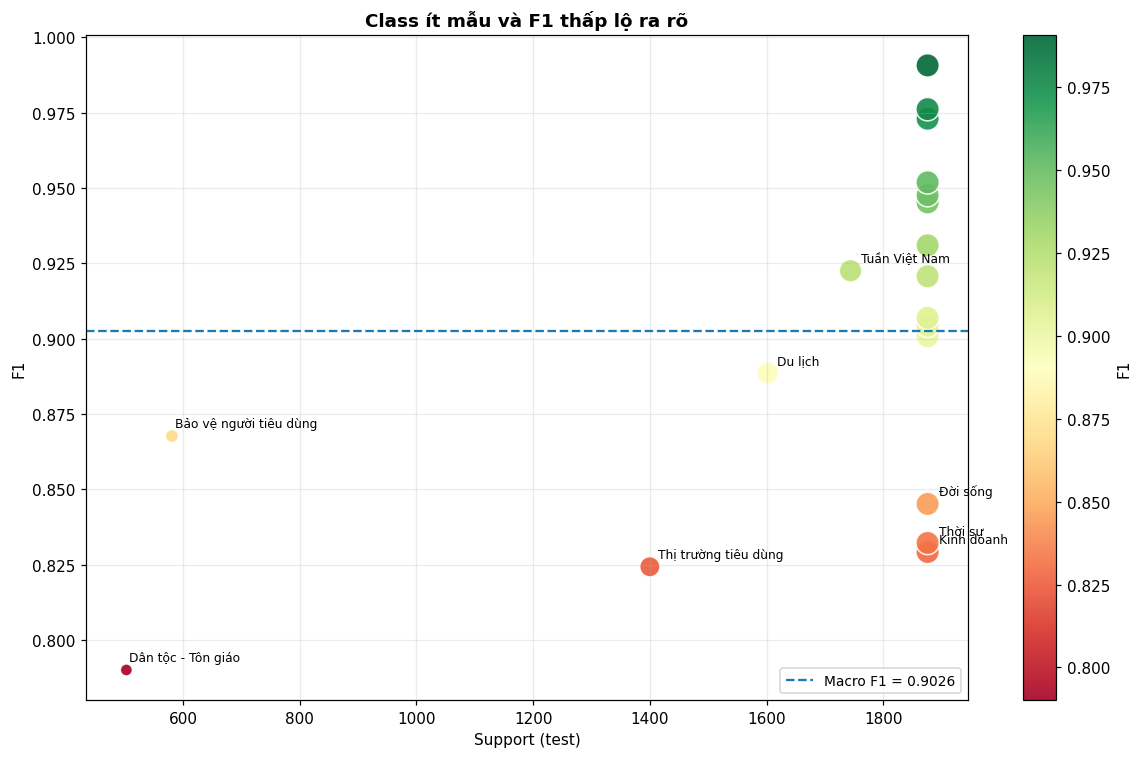

In [16]:
# -- 6.3 P/R/F1 by class + support vs F1 ---------------------------------------
_report_dict = classification_report(
    y_true_ids, y_pred_ids, target_names=classes, digits=4,
    output_dict=True, zero_division=0
)
_diag_rows = []
for cls in classes:
    _diag_rows.append({
        "class": cls,
        "precision": _report_dict[cls]["precision"],
        "recall": _report_dict[cls]["recall"],
        "f1": _report_dict[cls]["f1-score"],
        "support": int(_report_dict[cls]["support"]),
    })
_prf = pd.DataFrame(_diag_rows).sort_values("f1", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 10))
_y = np.arange(len(_prf))
_h = 0.24

ax.barh(_y - _h, _prf["precision"], height=_h, color="#6c8ebf", label="Precision")
ax.barh(_y,       _prf["recall"],    height=_h, color="#2a9d8f", label="Recall")
_bf1 = ax.barh(_y + _h, _prf["f1"],  height=_h,
               color=["#e76f51" if v < 0.80 else "#f4a261" if v < 0.90 else "#2a9d8f" for v in _prf["f1"]],
               label="F1")
for b, v in zip(_bf1, _prf["f1"]):
    ax.text(v + 0.004, b.get_y() + b.get_height()/2, f"{v:.3f}", va="center", fontsize=8)

ax.axvline(model_f1m, color="#1f77b4", ls="--", lw=2, label=f"Macro F1 = {model_f1m:.4f}")
ax.set_yticks(_y)
ax.set_yticklabels(_prf["class"], fontsize=9)
ax.set_xlim(0, 1.08)
ax.set_xlabel("Score")
ax.set_title("Class yếu lộ rõ nhất ở cân bằng Precision-Recall", fontweight="bold")
ax.grid(axis="x", alpha=0.25)
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
save_fig(fig, "04_f1_per_class.png")

fig2, ax2 = plt.subplots(figsize=(11, 7))
_sc = ax2.scatter(_prf["support"], _prf["f1"],
                  s=np.clip(_prf["support"] / 8, 30, 260),
                  c=_prf["f1"], cmap="RdYlGn", edgecolor="white", alpha=0.9)
for _, r in _prf.iterrows():
    if r["support"] < _prf["support"].quantile(0.25) or r["f1"] < 0.85:
        ax2.text(r["support"] * 1.01, r["f1"] + 0.003, r["class"], fontsize=8)
ax2.axhline(model_f1m, color="#1f77b4", ls="--", lw=1.5, label=f"Macro F1 = {model_f1m:.4f}")
ax2.set_xlabel("Support (test)")
ax2.set_ylabel("F1")
ax2.set_title("Class ít mẫu và F1 thấp lộ ra rõ", fontweight="bold")
ax2.grid(alpha=0.25)
ax2.legend(loc="lower right", fontsize=9)
fig2.colorbar(_sc, ax=ax2, label="F1")
fig2.tight_layout()
save_fig(fig2, "07_support_vs_f1.png")


[17:42:41][17187.4s] >> Đã lưu -> c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\results\05_training_curves.png


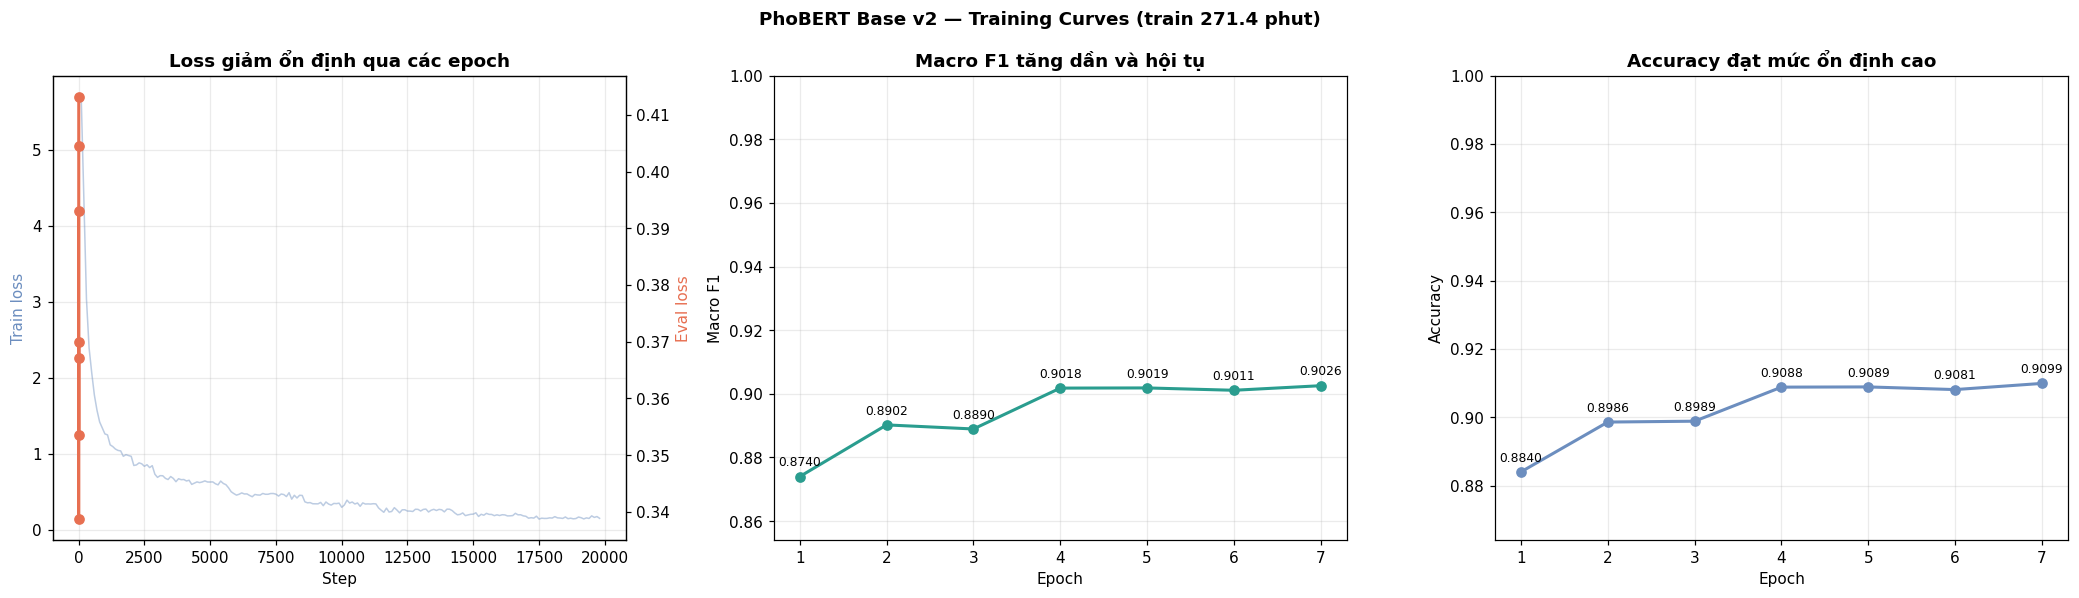

In [17]:
# -- 6.4 Training Curves --------------------------------------------------------
if not log_history:
    print("Không có log_history (load từ cache), bỏ qua biểu đồ quá trình huấn luyện.")
else:
    _train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
    _eval_logs  = [x for x in log_history if "eval_loss" in x]

    fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

    # 1) train/eval loss
    axes[0].plot([x["step"] for x in _train_logs], [x["loss"] for x in _train_logs],
                 alpha=0.45, color="#6c8ebf", lw=1.0, label="Train loss")
    _ax2 = axes[0].twinx()
    _ax2.plot([x["epoch"] for x in _eval_logs], [x["eval_loss"] for x in _eval_logs],
              marker="o", color="#e76f51", lw=2.0, label="Eval loss")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Train loss", color="#6c8ebf")
    _ax2.set_ylabel("Eval loss", color="#e76f51")
    axes[0].set_title("Loss giảm ổn định qua các epoch", fontweight="bold")
    axes[0].grid(alpha=0.25)

    # 2) eval macro F1
    _ep = [x["epoch"] for x in _eval_logs]
    _f1m = [x.get("eval_f1_macro", 0) for x in _eval_logs]
    axes[1].plot(_ep, _f1m, marker="o", color="#2a9d8f", lw=2)
    for x, y in zip(_ep, _f1m):
        axes[1].annotate(f"{y:.4f}", (x, y), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Macro F1")
    axes[1].set_ylim(max(0.7, min(_f1m) - 0.02), 1.0)
    axes[1].set_title("Macro F1 tăng dần và hội tụ", fontweight="bold")
    axes[1].grid(alpha=0.25)

    # 3) eval accuracy
    _ac = [x.get("eval_accuracy", 0) for x in _eval_logs]
    axes[2].plot(_ep, _ac, marker="o", color="#6c8ebf", lw=2)
    for x, y in zip(_ep, _ac):
        axes[2].annotate(f"{y:.4f}", (x, y), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Accuracy")
    axes[2].set_ylim(max(0.7, min(_ac) - 0.02), 1.0)
    axes[2].set_title("Accuracy đạt mức ổn định cao", fontweight="bold")
    axes[2].grid(alpha=0.25)

    fig.suptitle(f"PhoBERT Base v2 — Training Curves (train {train_time_sec/60:.1f} phut)",
                 fontsize=12, fontweight="bold")
    fig.tight_layout()
    save_fig(fig, "05_training_curves.png")


In [18]:
# -- 6.4 Tóm tắt kết quả -------------------------------------------------
print(f"\n{'='*60}")
print(f"  KẾT QUẢ - PhoBERT Base v2 Head-Tail")
print(f"{'='*60}")
print(f"\n  [CẤU HÌNH MÔ HÌNH]")
print(f"    Model        : {MODEL_NAME}")
print(f"    Strategy     : Head-Tail (127 + 127 tokens)")
print(f"    MAX_LENGTH   : {MAX_LENGTH}")
print(f"    Batch (eff)  : {BATCH_SIZE} - {GRAD_ACCUM} = {BATCH_SIZE*GRAD_ACCUM}")
print(f"    LR           : {LR}  |  Epochs: {NUM_EPOCHS}  |  BF16: {BF16}")
print(f"    class_weight : balanced")
print(f"\n  [DỮ LIỆU]")
print(f"    Số chủ đề    : {N_CLASSES}")
print(f"    Train        : {len(y_train):,} bài  ({(1-TEST_SIZE)*100:.0f}%)")
print(f"    Test         : {len(y_test):,} bài   ({TEST_SIZE*100:.0f}%)")
if train_time_sec:
    print(f"    Train time   : {train_time_sec/60:.1f} phút  ({train_time_sec/3600:.2f} giờ)")
print(f"\n  [HIỆU NĂNG TRÊN TẬP TEST]")
print(f"    Accuracy     : {model_acc:.4f}  ({model_acc*100:.2f}%)")
print(f"    F1-weighted  : {model_f1w:.4f}")
print(f"    F1-macro     : {model_f1m:.4f}")
print(f"\n  [5 CHỦ ĐỀ KHÓ PHÂN LOẠI NHẤT]")
for _cls, _v in sorted(f1_per_class.items(), key=lambda x: x[1])[:5]:
    print(f"    {_cls:<38}  F1 = {_v:.4f}")
print(f"\n  [5 CHỦ ĐỀ DỄ PHÂN LOẠI NHẤT]")
for _cls, _v in sorted(f1_per_class.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"    {_cls:<38}  F1 = {_v:.4f}")

_cm2      = confusion_matrix(y_true_ids, y_pred_ids, labels=list(range(N_CLASSES)))
_confused = sorted(
    [(_cm2[i,j], classes[i], classes[j])
     for i in range(N_CLASSES) for j in range(N_CLASSES) if i!=j and _cm2[i,j]>0],
    reverse=True
)
print(f"\n  [TOP 5 CẶP CHỦ ĐỀ BỊ NHẦM NHIỀU NHẤT]")
for _cnt, _tr, _pr in _confused[:5]:
    print(f"    {_tr:<28} -> {_pr:<28}  {_cnt:>4} lần")

print(f"\n  [FILE KẾT QUẢ ĐÃ LƯU]")
for _f in sorted(os.listdir(RESULTS_DIR)):
    _fp = os.path.join(RESULTS_DIR, _f)
    print(f"    {_f:<38}  ({os.path.getsize(_fp)/1024:.1f} KB)")
print(f"\n{'='*60}")


  KẾT QUẢ - PhoBERT Base v2 Head-Tail

  [CẤU HÌNH MÔ HÌNH]
    Model        : vinai/phobert-base-v2
    Strategy     : Head-Tail (127 + 127 tokens)
    MAX_LENGTH   : 256
    Batch (eff)  : 32 - 2 = 64
    LR           : 2e-05  |  Epochs: 7  |  BF16: True
    class_weight : balanced

  [DỮ LIỆU]
    Số chủ đề    : 19
    Train        : 181,860 bài  (85%)
    Test         : 32,094 bài   (15%)
    Train time   : 271.4 phút  (4.52 giờ)

  [HIỆU NĂNG TRÊN TẬP TEST]
    Accuracy     : 0.9099  (90.99%)
    F1-weighted  : 0.9100
    F1-macro     : 0.9026

  [5 CHỦ ĐỀ KHÓ PHÂN LOẠI NHẤT]
    Dân tộc - Tôn giáo                      F1 = 0.7901
    Thị trường tiêu dùng                    F1 = 0.8243
    Kinh doanh                              F1 = 0.8293
    Thời sự                                 F1 = 0.8322
    Đời sống                                F1 = 0.8452

  [5 CHỦ ĐỀ DỄ PHÂN LOẠI NHẤT]
    Thể thao                                F1 = 0.9907
    Ô tô - Xe máy                          

---
## Section 7 - Export Model Config

Lưu `label_config.json` vào `model/` như metadata đi kèm model để inference có thể dùng lại cấu hình nhãn và tiền xử lý.
Model + tokenizer đã được lưu tự động bởi Trainer ở Section 5.

In [19]:
# --
_label_config = {
    "model_name":  MODEL_NAME,
    "strategy":    "head_tail",
    "max_length":  MAX_LENGTH,
    "n_classes":   N_CLASSES,
    "classes":     classes,
    "label2id":    label2id,
    "id2label":    {str(k): v for k, v in id2label.items()},
    "preprocessing": {
        "title_weight":  1,
        "lowercase":     True,
        "remove_punct":  True,
        "remove_digits": True,
        "tokenizer":     "pyvi.ViTokenizer",
        "stopwords":     False,
    },
}
with open(LABEL_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(_label_config, f, ensure_ascii=False, indent=2)
log(f"Đã lưu: {LABEL_CONFIG_PATH}", "SAVE")

# --
print(f"\n  [SMOKE TEST - 3 bài ngẫu nhiên]\n")

def _infer(title, content):
    from pyvi import ViTokenizer
    text  = (str(title) + " " + str(content)).lower()
    text  = re.sub(r"[^\w\s]", " ", text)
    text  = re.sub(r"\d+",     " ", text)
    text  = ViTokenizer.tokenize(text)
    text  = re.sub(r"\s+",     " ", text).strip()
    half  = (MAX_LENGTH - 2) // 2
    enc_full = tokenizer.encode(text, add_special_tokens=False, truncation=False)
    if len(enc_full) <= MAX_LENGTH - 2:
        enc = tokenizer(text, truncation=True, padding="max_length", max_length=MAX_LENGTH,
                        return_tensors="pt")
    else:
        head = enc_full[:half]; tail = enc_full[-half:]
        ids  = [tokenizer.cls_token_id] + head + tail + [tokenizer.sep_token_id]
        ids += [tokenizer.pad_token_id] * (MAX_LENGTH - len(ids))
        enc  = {"input_ids": torch.tensor([ids]),
                "attention_mask": torch.tensor([[1]*min(len(enc_full)+2, MAX_LENGTH)
                                                 + [0]*(MAX_LENGTH - min(len(enc_full)+2, MAX_LENGTH))])}
    with torch.no_grad():
        logits = model_eval(**{k: v.to(device) for k,v in enc.items()}).logits
    return classes[logits.argmax(-1).item()]

_rng = np.random.default_rng(42)
_ok  = 0
for _i in _rng.choice(len(df_raw), size=3, replace=False):
    _row  = df_raw.iloc[_i]
    _pred = _infer(_row["title"], _row["content"])
    _ok  += int(_pred == _row["label"])
    _mark = "[OK]" if _pred == _row["label"] else "[LỖI]"
    print(f"  {_mark}  Thật: {_row['label']:<32}  Dự đoán: {_pred}")
print(f"\n  Smoke test: {_ok}/3 đúng")

print(f"\n  [FILE ĐÃ LƯU TRONG model/]")
for _f in sorted(os.listdir(MODEL_DIR)):
    _fp = os.path.join(MODEL_DIR, _f)
    if os.path.isfile(_fp):
        print(f"    {_f:<35}  ({os.path.getsize(_fp)/1024:.1f} KB)")

[17:42:42][17187.6s] >> Đã lưu: c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\model\label_config.json

  [SMOKE TEST - 3 bài ngẫu nhiên]

  [OK]  Thật: Sức khỏe                          Dự đoán: Sức khỏe
  [OK]  Thật: Bất động sản                      Dự đoán: Bất động sản
  [OK]  Thật: Thể thao                          Dự đoán: Thể thao

  Smoke test: 3/3 đúng

  [FILE ĐÃ LƯU TRONG model/]
    added_tokens.json                    (0.0 KB)
    bpe.codes                            (1108.6 KB)
    config.json                          (2.2 KB)
    label_config.json                    (1.9 KB)
    model.safetensors                    (527417.6 KB)
    tokenizer_config.json                (1.2 KB)
    train_history.pkl                    (11.9 KB)
    training_args.bin                    (5.1 KB)
    vocab.txt                            (874.3 KB)


---
## Section 8 - Threshold Calibration

Thay vì `argmax(logits)`, tìm ngưỡng tối ưu **riêng cho từng class** để cải thiện F1 các class yếu.

**Cơ chế:** `predict = argmax(probs / thresholds)` - class nào có ngưỡng cao hơn sẽ khó được chọn hơn (giảm dự đoán quá mức), class nào có ngưỡng thấp hơn sẽ dễ được chọn hơn (giảm dự đoán thiếu).

> **Lưu ý:** Thresholds được tìm trên test set nên hơi optimistic. Trong production nên dùng validation set riêng.

In [20]:
# -- 8.0 Temperature scaling: compute once, reuse if cached --------------------
from scipy.optimize import minimize_scalar
from scipy.special import softmax as sp_softmax
import numpy as _np

_THRESHOLD_PATH = os.path.join(MODEL_DIR, "thresholds.json")
_logits = raw_logits
_labels = np.array(y_true_ids)

if os.path.exists(_THRESHOLD_PATH):
    with open(_THRESHOLD_PATH, "r", encoding="utf-8") as f:
        _thr_cache = json.load(f)
    T_OPTIMAL = float(_thr_cache.get("temperature", 1.0))
    log(f"Đã có cache threshold: {_THRESHOLD_PATH} -> bỏ qua tim Temperature", "OK")
else:
    def _nll(T):
        scaled = _logits / max(T, 1e-3)
        p = sp_softmax(scaled, axis=1)
        true_p = p[np.arange(len(_labels)), _labels]
        return -np.mean(np.log(true_p + 1e-10))

    _result = minimize_scalar(_nll, bounds=(0.5, 5.0), method="bounded")
    T_OPTIMAL = float(_result.x)
    log("Da tim xong Temperature Scaling", "OK")

def _nll_eval(T):
    scaled = _logits / max(T, 1e-3)
    p = sp_softmax(scaled, axis=1)
    true_p = p[np.arange(len(_labels)), _labels]
    return -np.mean(np.log(true_p + 1e-10))

def _ece(logits, labels, T=1.0, n_bins=15):
    p = sp_softmax(logits / T, axis=1)
    conf = p.max(axis=1)
    pred = p.argmax(axis=1)
    acc_bins, conf_bins, counts = [], [], []
    for b in range(n_bins):
        lo, hi = b/n_bins, (b+1)/n_bins
        mask = (conf >= lo) & (conf < hi)
        if mask.sum() == 0:
            continue
        acc_bins.append((pred[mask] == labels[mask]).mean())
        conf_bins.append(conf[mask].mean())
        counts.append(mask.sum())
    counts = np.array(counts)
    return np.sum(counts * np.abs(np.array(acc_bins) - np.array(conf_bins))) / counts.sum()

_nll_before = _nll_eval(1.0)
_nll_after  = _nll_eval(T_OPTIMAL)
_ece_before = _ece(_logits, _labels, T=1.0)
_ece_after  = _ece(_logits, _labels, T=T_OPTIMAL)

print(f"  T_optimal = {T_OPTIMAL:.4f}")
print(f"  NLL   : {_nll_before:.4f} -> {_nll_after:.4f}  (delta {_nll_after-_nll_before:+.4f})")
print(f"  ECE   : {_ece_before:.4f} -> {_ece_after:.4f}  (delta {_ece_after-_ece_before:+.4f})")


[17:42:42][17188.0s] OK Da tim xong Temperature Scaling
  T_optimal = 1.4613
  NLL   : 0.3704 -> 0.3128  (delta -0.0577)
  ECE   : 0.0568 -> 0.0198  (delta -0.0371)


In [21]:
# -- 8.1 Threshold calibration: compute once, reuse if cached ------------------
from scipy.special import softmax as sp_softmax

y_true_arr = np.array(y_true_ids)
probs = sp_softmax(raw_logits / T_OPTIMAL, axis=1)

# Baseline (không dùng threshold)
_base_preds = np.argmax(probs, axis=1)
_base_f1 = f1_score(y_true_arr, _base_preds, average=None, labels=list(range(N_CLASSES)))

if os.path.exists(_THRESHOLD_PATH):
    thresholds = np.array([_thr_cache.get("thresholds", {}).get(cls, 1.0) for cls in classes], dtype=float)
    log("Đã có thresholds.json -> bỏ qua grid search, chỉ tải lại để vẽ và báo cáo", "OK")
else:
    log("Tìm threshold tối ưu - grid search (3 lượt)...")
    thresholds = np.ones(N_CLASSES)
    SEARCH_GRID = np.linspace(0.3, 3.5, 200)

    for _pass in range(3):
        _improved = 0
        for cls_idx in range(N_CLASSES):
            best_t = thresholds[cls_idx]
            best_f1 = f1_score(y_true_arr, np.argmax(probs / thresholds, axis=1), labels=[cls_idx], average=None)[0]
            for t in SEARCH_GRID:
                _t_vec = thresholds.copy()
                _t_vec[cls_idx] = t
                _preds = np.argmax(probs / _t_vec, axis=1)
                _f1 = f1_score(y_true_arr, _preds, labels=[cls_idx], average=None)[0]
                if _f1 > best_f1 + 1e-5:
                    best_f1 = _f1
                    best_t = t
            if abs(best_t - thresholds[cls_idx]) > 1e-4:
                _improved += 1
            thresholds[cls_idx] = best_t
        log(f"  Pass {_pass+1}/3 - {_improved} lớp thay đổi threshold")

_cal_preds = np.argmax(probs / thresholds, axis=1)
_cal_f1 = f1_score(y_true_arr, _cal_preds, average=None, labels=list(range(N_CLASSES)))

cal_acc = accuracy_score(y_true_arr, _cal_preds)
cal_f1w = f1_score(y_true_arr, _cal_preds, average="weighted")
cal_f1m = f1_score(y_true_arr, _cal_preds, average="macro")

print(f"\n{'='*72}")
print(f"  {'Metric':<20}  {'Before':>10}  {'After':>10}  {'Delta':>8}")
print(f"  {'-'*68}")
for _name, _before, _after in [
    ("Accuracy", model_acc, cal_acc),
    ("F1-weighted", model_f1w, cal_f1w),
    ("F1-macro", model_f1m, cal_f1m),
]:
    _delta = _after - _before
    _sign = "+" if _delta >= 0 else ""
    print(f"  {_name:<20}  {_before:>10.4f}  {_after:>10.4f}  {_sign}{_delta:>7.4f}")
print(f"{'='*72}")

print(f"\n  {'Class':<38}  {'Before':>7}  {'After':>7}  {'Delta':>7}  {'Threshold':>10}")
print(f"  {'-'*72}")
for i, cls in enumerate(classes):
    _b = _base_f1[i]
    _a = _cal_f1[i]
    _d = _a - _b
    _sign = "+" if _d >= 0 else ""
    _mark = " ^" if _d > 0.005 else (" v" if _d < -0.005 else "")
    print(f"  {cls:<38}  {_b:>7.4f}  {_a:>7.4f}  {_sign}{_d:>6.4f}  {thresholds[i]:>10.4f}{_mark}")


[17:42:42][17188.0s] i Tìm threshold tối ưu - grid search (3 lượt)...
[17:43:01][17207.1s] i   Pass 1/3 - 17 lớp thay đổi threshold
[17:43:20][17225.8s] i   Pass 2/3 - 15 lớp thay đổi threshold
[17:43:38][17244.2s] i   Pass 3/3 - 6 lớp thay đổi threshold

  Metric                    Before       After     Delta
  --------------------------------------------------------------------
  Accuracy                  0.9099      0.9138  + 0.0038
  F1-weighted               0.9100      0.9139  + 0.0039
  F1-macro                  0.9026      0.9066  + 0.0040

  Class                                    Before    After    Delta   Threshold
  ------------------------------------------------------------------------
  Bạn đọc                                  0.9477   0.9510  +0.0034      2.7603
  Bảo vệ người tiêu dùng                   0.8677   0.8761  +0.0083      0.3322 ^
  Bất động sản                             0.9207   0.9226  +0.0019      0.8789
  Chính trị                                0.90

[17:43:38][17244.5s] >> Đã lưu -> c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\results\06_threshold_calibration.png


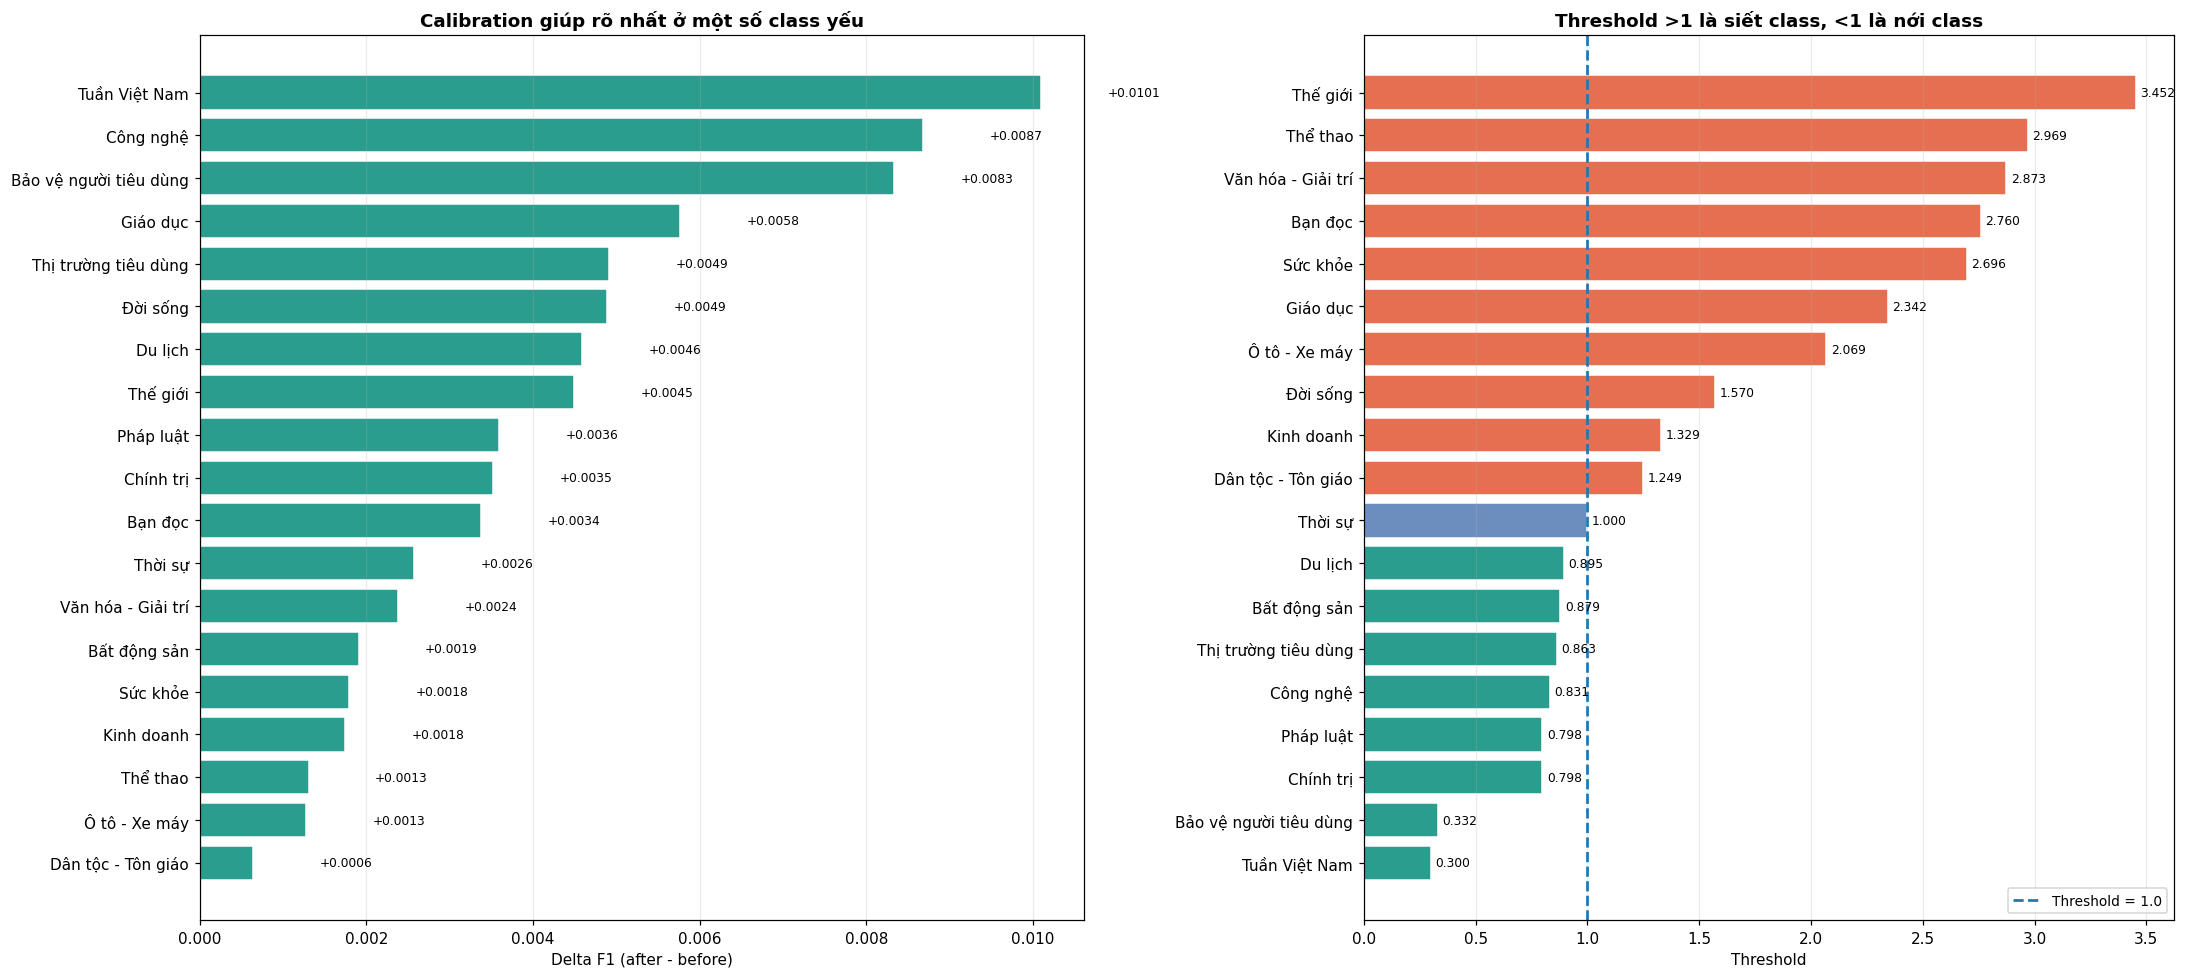

In [22]:
# -- 8.2 Delta F1 + threshold theo từng chủ đề ----------------------------------------
_items = []
for i, cls in enumerate(classes):
    _items.append({
        "class": cls,
        "f1_before": float(_base_f1[i]),
        "f1_after": float(_cal_f1[i]),
        "delta": float(_cal_f1[i] - _base_f1[i]),
        "threshold": float(thresholds[i]),
    })
_df = pd.DataFrame(_items)

_df_delta = _df.sort_values("delta", ascending=False).reset_index(drop=True)
_df_thr = _df.sort_values("threshold", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 9), gridspec_kw={"width_ratios": [1.2, 1.1]})

# Delta F1
_colors_d = ["#2a9d8f" if v >= 0 else "#e76f51" for v in _df_delta["delta"]]
_bd = axes[0].barh(_df_delta["class"], _df_delta["delta"], color=_colors_d, edgecolor="white")
axes[0].invert_yaxis()
for b, v in zip(_bd, _df_delta["delta"]):
    axes[0].text(v + (0.0008 if v >= 0 else -0.0008), b.get_y() + b.get_height()/2,
                 f"{v:+.4f}", va="center", ha="left" if v >= 0 else "right", fontsize=8)
axes[0].axvline(0, color="#555", lw=1)
axes[0].set_title("Calibration giúp rõ nhất ở một số class yếu", fontweight="bold")
axes[0].set_xlabel("Delta F1 (after - before)")
axes[0].grid(axis="x", alpha=0.25)

# Threshold theo từng chủ đề
_colors_t = ["#e76f51" if t > 1.0 else "#2a9d8f" if t < 1.0 else "#6c8ebf" for t in _df_thr["threshold"]]
_bt = axes[1].barh(_df_thr["class"], _df_thr["threshold"], color=_colors_t, edgecolor="white")
axes[1].invert_yaxis()
for b, v in zip(_bt, _df_thr["threshold"]):
    axes[1].text(v + 0.02, b.get_y() + b.get_height()/2, f"{v:.3f}", va="center", fontsize=8)
axes[1].axvline(1.0, color="#1f77b4", ls="--", lw=1.8, label="Threshold = 1.0")
axes[1].set_title("Threshold >1 là siết class, <1 là nới class", fontweight="bold")
axes[1].set_xlabel("Threshold")
axes[1].grid(axis="x", alpha=0.25)
axes[1].legend(loc="lower right", fontsize=9)

fig.tight_layout()
save_fig(fig, "06_threshold_calibration.png")


In [23]:
# -- 8.3 Save thresholds only when cache missing; otherwise just sync config ----
_threshold_path = os.path.join(MODEL_DIR, "thresholds.json")

if not os.path.exists(_threshold_path):
    _threshold_config = {
        "temperature": T_OPTIMAL,
        "method": "per_class_f1_grid_search",
        "search_range": [0.3, 3.5],
        "n_grid": 200,
        "n_passes": 3,
        "usage": "predict = argmax(softmax(logits) / thresholds)",
        "thresholds": {cls: float(thresholds[i]) for i, cls in enumerate(classes)},
        "metrics_before": {"accuracy": model_acc, "f1_weighted": model_f1w, "f1_macro": model_f1m},
        "metrics_after": {"accuracy": cal_acc, "f1_weighted": cal_f1w, "f1_macro": cal_f1m},
    }
    with open(_threshold_path, "w", encoding="utf-8") as f:
        json.dump(_threshold_config, f, ensure_ascii=False, indent=2)
    log(f"Đã lưu thresholds: {_threshold_path}", "SAVE")
else:
    log(f"Đã có cache threshold: {_threshold_path} -> không ghi đè", "OK")

# Cập nhật label_config.json để app biết có threshold
with open(LABEL_CONFIG_PATH, "r", encoding="utf-8") as f:
    _lc = json.load(f)
_lc["threshold_file"] = "thresholds.json"
_lc["use_threshold_calibration"] = True
with open(LABEL_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(_lc, f, ensure_ascii=False, indent=2)
log("Đã cập nhật label_config.json với threshold_file", "SAVE")

print(f"\n  [THRESHOLDS PER CLASS]")
print(f"  {'Class':<38}  {'Threshold':>10}  {'Y nghia'}")
print(f"  {'-'*70}")
for i, cls in enumerate(classes):
    t = thresholds[i]
    if t > 1.2:
        meaning = "Giảm dự đoán quá mức"
    elif t < 0.8:
        meaning = "Giảm dự đoán thiếu"
    else:
        meaning = "Gần như không đổi"
    print(f"  {cls:<38}  {t:>10.4f}  {meaning}")


[17:43:39][17244.7s] >> Đã lưu thresholds: c:\Users\DELL\Downloads\HTTM\VietNamNet News Classification\PhoBERT\model\thresholds.json
[17:43:39][17244.7s] >> Đã cập nhật label_config.json với threshold_file

  [THRESHOLDS PER CLASS]
  Class                                    Threshold  Y nghia
  ----------------------------------------------------------------------
  Bạn đọc                                     2.7603  Giảm dự đoán quá mức
  Bảo vệ người tiêu dùng                      0.3322  Giảm dự đoán thiếu
  Bất động sản                                0.8789  Gần như không đổi
  Chính trị                                   0.7985  Giảm dự đoán thiếu
  Công nghệ                                   0.8307  Gần như không đổi
  Du lịch                                     0.8950  Gần như không đổi
  Dân tộc - Tôn giáo                          1.2487  Giảm dự đoán quá mức
  Giáo dục                                    2.3422  Giảm dự đoán quá mức
  Kinh doanh                                  

---
## Section 9 - Chẩn Đoán

Section nay chi print ra cac tin hieu can xem de cai thien model sau train va calibration, không fine-tune them.


In [24]:
# -- 9.1 Build before/after diagnostic table ----------------------------------
if "_cal_preds" not in dir():
    probs = sp_softmax(raw_logits / T_OPTIMAL, axis=1)
    _cal_preds = np.argmax(probs / thresholds, axis=1)

_base_report = classification_report(
    y_true_ids, y_pred_ids, target_names=classes, digits=4,
    output_dict=True, zero_division=0
)
_cal_report = classification_report(
    y_true_ids, _cal_preds, target_names=classes, digits=4,
    output_dict=True, zero_division=0
)
_diag_df = pd.DataFrame([
    {
        "class": cls,
        "support": int(_base_report[cls]["support"]),
        "precision_before": _base_report[cls]["precision"],
        "recall_before":    _base_report[cls]["recall"],
        "f1_before":        _base_report[cls]["f1-score"],
        "precision_after":  _cal_report[cls]["precision"],
        "recall_after":     _cal_report[cls]["recall"],
        "f1_after":         _cal_report[cls]["f1-score"],
        "threshold":        float(thresholds[classes.index(cls)]),
    }
    for cls in classes
])
_diag_df["delta_f1"] = _diag_df["f1_after"] - _diag_df["f1_before"]
_diag_df["pr_gap_after"] = _diag_df["recall_after"] - _diag_df["precision_after"]
_diag_df["support_pct"] = _diag_df["support"] / max(int(_diag_df["support"].sum()), 1)

print(f"\n{'='*92}")
print("[TÓM TẮT CHẨN ĐOÁN PHOBERT]")
print(f"  F1-macro before : {model_f1m:.4f}")
print(f"  F1-macro after  : {cal_f1m:.4f}  ({cal_f1m - model_f1m:+.4f})")
print(f"  F1-weighted bef.: {model_f1w:.4f}")
print(f"  F1-weighted aft.: {cal_f1w:.4f}  ({cal_f1w - model_f1w:+.4f})")
print(f"  Accuracy before : {model_acc:.4f}")
print(f"  Accuracy after  : {cal_acc:.4f}  ({cal_acc - model_acc:+.4f})")
print(f"  Temperature     : {T_OPTIMAL:.4f}")
print(f"{'='*92}")

print("\n[5 CHỦ ĐỀ YẾU NHẤT SAU CALIBRATION]")
for _, r in _diag_df.sort_values(["f1_after", "support"], ascending=[True, True]).head(5).iterrows():
    print(f"  {r['class']:<30}  F1={r['f1_after']:.4f}  P={r['precision_after']:.4f}  R={r['recall_after']:.4f}  số_mẫu={int(r['support'])}")

print("\n[5 CHỦ ĐỀ ÍT MẪU NHẤT]")
for _, r in _diag_df.sort_values(["support", "f1_after"], ascending=[True, True]).head(5).iterrows():
    print(f"  {r['class']:<30}  số_mẫu={int(r['support']):>5}  ({r['support_pct']*100:>5.2f}%)  F1_sau={r['f1_after']:.4f}")

print("\n[5 CHỦ ĐỀ CẢI THIỆN NHIỀU NHẤT SAU CALIBRATION]")
for _, r in _diag_df.sort_values("delta_f1", ascending=False).head(5).iterrows():
    print(f"  {r['class']:<30}  trước={r['f1_before']:.4f}  sau={r['f1_after']:.4f}  chênh_lệch={r['delta_f1']:+.4f}  thr={r['threshold']:.4f}")

print("\n[5 CHỦ ĐỀ GIẢM NHIỀU NHẤT SAU CALIBRATION]")
for _, r in _diag_df.sort_values("delta_f1", ascending=True).head(5).iterrows():
    print(f"  {r['class']:<30}  trước={r['f1_before']:.4f}  sau={r['f1_after']:.4f}  chênh_lệch={r['delta_f1']:+.4f}  thr={r['threshold']:.4f}")

print("\n[CÁC CHỦ ĐỀ CÓ RECALL THẤP SAU CALIBRATION]")
for _, r in _diag_df.sort_values("pr_gap_after", ascending=True).head(5).iterrows():
    print(f"  {r['class']:<30}  độ_lệch={r['pr_gap_after']:+.4f}  P={r['precision_after']:.4f}  R={r['recall_after']:.4f}  thr={r['threshold']:.4f}")

print("\n[CÁC CHỦ ĐỀ CÓ PRECISION THẤP SAU CALIBRATION]")
for _, r in _diag_df.sort_values("pr_gap_after", ascending=False).head(5).iterrows():
    print(f"  {r['class']:<30}  độ_lệch={r['pr_gap_after']:+.4f}  P={r['precision_after']:.4f}  R={r['recall_after']:.4f}  thr={r['threshold']:.4f}")

# -- 9.2 Top confusion pairs after calibration -------------------------------
_cm_cal = confusion_matrix(y_true_ids, _cal_preds, labels=list(range(N_CLASSES)))
_pairs = []
for i, true_cls in enumerate(classes):
    _support = max(int(_cm_cal[i].sum()), 1)
    for j, pred_cls in enumerate(classes):
        if i == j or _cm_cal[i, j] == 0:
            continue
        _pairs.append({
            "count": int(_cm_cal[i, j]),
            "rate":  float(_cm_cal[i, j] / _support),
            "true":  true_cls,
            "pred":  pred_cls,
        })
_pairs_df = pd.DataFrame(_pairs).sort_values(["count", "rate"], ascending=[False, False]) if _pairs else pd.DataFrame(columns=["count", "rate", "true", "pred"])

print("\n[TOP 8 CẶP CHỦ ĐỀ BỊ NHẦM NHIỀU NHẤT SAU CALIBRATION]")
if len(_pairs_df) == 0:
    print("  Không có cặp nhầm lẫn ngoài đường chéo.")
else:
    for _, r in _pairs_df.head(8).iterrows():
        print(f"  {r['true']:<28} -> {r['pred']:<28}  {int(r['count']):>4} lần  ({r['rate']*100:>5.2f}%)")

# -- 9.3 Next-step hints -----------------------------------------------------
print("\n[GỢI Ý BƯỚC TIẾP THEO CHO PHOBERT]")
if (cal_f1w - cal_f1m) > 0.06:
    print("  - Weighted vẫn cao hơn macro khá nhiều -> dấu hiệu lệch lớp vẫn còn; hãy ưu tiên các lớp ít mẫu và các lớp chuyên biệt.")
else:
    print("  - Weighted và macro đã khá gần nhau -> nên tập trung vào các cặp nhầm lẫn mạnh nhất.")

_thr_high = _diag_df[_diag_df["threshold"] > 1.4].sort_values("threshold", ascending=False)["class"].tolist()
_thr_low = _diag_df[_diag_df["threshold"] < 0.8].sort_values("threshold")["class"].tolist()
_low_f1 = _diag_df[_diag_df["f1_after"] < 0.80].sort_values("f1_after")["class"].tolist()

if _thr_high:
    print(f"  - Các lớp có threshold cao: {', '.join(_thr_high[:6])}{' ...' if len(_thr_high) > 6 else ''}")
    print("    Hãy kiểm tra xem các lớp này có thực sự bị dự đoán quá nhiều không; nếu recall giảm quá mạnh, hãy hạ threshold hoặc bổ sung dữ liệu.")
if _thr_low:
    print(f"  - Các lớp có threshold thấp: {', '.join(_thr_low[:6])}{' ...' if len(_thr_low) > 6 else ''}")
    print("    Nếu precision ở đây vẫn thấp, calibration chỉ xử lý phần ngọn; cần xem lại dữ liệu, class weight và các cặp nhầm lẫn.")
if _low_f1:
    print(f"  - Các lớp có F1_sau < 0.80: {', '.join(_low_f1[:6])}{' ...' if len(_low_f1) > 6 else ''}")
    print("    Hãy ưu tiên bổ sung mẫu thật, rà soát nhãn, hoặc tăng class weight một cách thận trọng cho các lớp này.")

print("  - Nếu một lớp cải thiện chủ yếu nhờ threshold tuning, đặc trưng của mô hình gốc có thể vẫn yếu; không nên phụ thuộc lâu dài chỉ vào calibration.")
print("  - Nếu các cặp nhầm lẫn giống nhau lặp lại nhiều lần, hãy đọc trực tiếp các văn bản thuộc đúng các cặp đó; sửa dữ liệu thường hiệu quả hơn tinh chỉnh siêu tham số diện rộng.")
print("  - Nếu macro F1 vẫn thấp sau calibration, hãy giữ LR/epoch hiện tại và thử vòng sau với class boost thận trọng, sampling, hoặc bổ sung dữ liệu cho lớp hiếm.")



[TÓM TẮT CHẨN ĐOÁN PHOBERT]
  F1-macro before : 0.9026
  F1-macro after  : 0.9066  (+0.0040)
  F1-weighted bef.: 0.9100
  F1-weighted aft.: 0.9139  (+0.0039)
  Accuracy before : 0.9099
  Accuracy after  : 0.9138  (+0.0038)
  Temperature     : 1.4613

[5 CHỦ ĐỀ YẾU NHẤT SAU CALIBRATION]
  Dân tộc - Tôn giáo              F1=0.7907  P=0.7400  R=0.8489  số_mẫu=503
  Thị trường tiêu dùng            F1=0.8293  P=0.8243  R=0.8343  số_mẫu=1400
  Kinh doanh                      F1=0.8310  P=0.8546  R=0.8086  số_mẫu=1876
  Thời sự                         F1=0.8348  P=0.8359  R=0.8337  số_mẫu=1876
  Đời sống                        F1=0.8501  P=0.8570  R=0.8433  số_mẫu=1876

[5 CHỦ ĐỀ ÍT MẪU NHẤT]
  Dân tộc - Tôn giáo              số_mẫu=  503  ( 1.57%)  F1_sau=0.7907
  Bảo vệ người tiêu dùng          số_mẫu=  581  ( 1.81%)  F1_sau=0.8761
  Thị trường tiêu dùng            số_mẫu= 1400  ( 4.36%)  F1_sau=0.8293
  Du lịch                         số_mẫu= 1602  ( 4.99%)  F1_sau=0.8933
  Tuần Việt Nam 